In [47]:
import pyvista as pv
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd

import os
    
import imageio

%matplotlib inline

from scipy.stats import binned_statistic_2d
import psutil
import math
from tqdm import tqdm


# 0. create case numbers and assign names

In [48]:
matrix_folder = '~/work/gpusph/spheric2022_gpusph/matrix_tests/'
Case_folder_a = []
fig_folder_a = []
slope_case_a = []
pamp_case_a = []
cob_case_a = []
ele_case_a = []

ncase = 0
for islope in [1, 2, 3]:
    print(f"Processing slope {islope}...")
    # for ipamp in [2.0]:
    # if islope == 3:
    #     ipamp_list = [1.5, 2.0]
    # else:
    ipamp_list = [1.5, 2.0, 2.5]
    for ipamp in ipamp_list:
        print(f"  Processing pamp {ipamp}...")
        for icase in range(9):
            # print(f"    Processing case {icase}...")
            Case_folder0 = f'{matrix_folder}mywaveroughtank_v5_c_slope{islope}_pamp{ipamp}_case{icase}/data/'
            Case_folder_a.append(Case_folder0)
            slope_case_a.append(islope)
            pamp_case_a.append(ipamp)
            fig_folder0 = f'figure_matrix_slope{islope}_pamp{ipamp}_case{icase}/'
            fig_folder_a.append(fig_folder0)
            if icase <=2:
                ele_case_a.append(1.5)
            elif icase <=5:
                ele_case_a.append(1.0)
            else:
                ele_case_a.append(2.0)
            if icase % 3 == 0:
                cob_case_a.append(1.0)
            elif icase % 3 == 1:
                cob_case_a.append(0.5)
            else:
                cob_case_a.append(0.0)
            ncase += 1
            

print(f"Total cases processed: {ncase}")
for i in range(ncase):
    # print(f"Case {i+1}: Slope={slope_case_a[i]}, Pamp={pamp_case_a[i]}, Cob={cob_case_a[i]}, Ele={ele_case_a[i]}")
    print("Case folders:", Case_folder_a[i], "Figure folders:", fig_folder_a[i])
cname = ['cob:1.0; ele:1.5','cob:0.5; ele:1.5','cob:0.0; ele:1.5',
         'cob:1.0; ele:1.0','cob:0.5; ele:1.0','cob:0.0; ele:1.0',
         'cob:1.0; ele:2.0','cob:0.5; ele:2.0','cob:0.0; ele:2.0']
# try:
#     os.mkdir(fig_folder)
#     print(f"Folder '{fig_folder}' created.")
# except FileExistsError:
#     print(f"Folder '{fig_folder}' already exists.")

Processing slope 1...
  Processing pamp 1.5...
  Processing pamp 2.0...
  Processing pamp 2.5...
Processing slope 2...
  Processing pamp 1.5...
  Processing pamp 2.0...
  Processing pamp 2.5...
Processing slope 3...
  Processing pamp 1.5...
  Processing pamp 2.0...
  Processing pamp 2.5...
Total cases processed: 81
Case folders: ~/work/gpusph/spheric2022_gpusph/matrix_tests/mywaveroughtank_v5_c_slope1_pamp1.5_case0/data/ Figure folders: figure_matrix_slope1_pamp1.5_case0/
Case folders: ~/work/gpusph/spheric2022_gpusph/matrix_tests/mywaveroughtank_v5_c_slope1_pamp1.5_case1/data/ Figure folders: figure_matrix_slope1_pamp1.5_case1/
Case folders: ~/work/gpusph/spheric2022_gpusph/matrix_tests/mywaveroughtank_v5_c_slope1_pamp1.5_case2/data/ Figure folders: figure_matrix_slope1_pamp1.5_case2/
Case folders: ~/work/gpusph/spheric2022_gpusph/matrix_tests/mywaveroughtank_v5_c_slope1_pamp1.5_case3/data/ Figure folders: figure_matrix_slope1_pamp1.5_case3/
Case folders: ~/work/gpusph/spheric2022_gpu

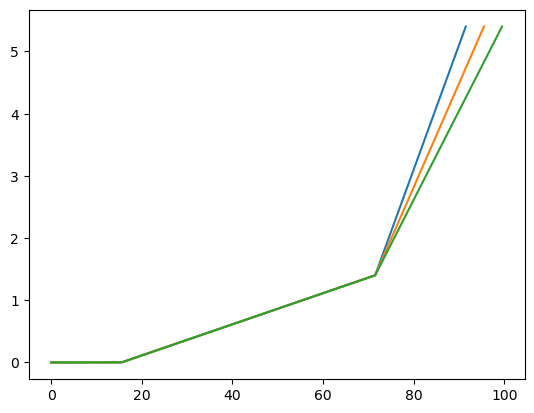

In [49]:
# # load the DEM file
dem_file1 = '/home/ceoas/liux8/work/gpusph/spheric2022_gpusph/preprocessing/cobble_slope_design/cobble_surface_with_slope_wave_v10_fac0.0.txt'
dem_data1 = np.loadtxt(dem_file1, skiprows=6)

dem_file2 = '/home/ceoas/liux8/work/gpusph/spheric2022_gpusph/preprocessing/cobble_slope_design/cobble_surface_with_slope-1-6_wave_v10_fac0.0.txt'
dem_data2 = np.loadtxt(dem_file2, skiprows=6)

dem_file3 = '/home/ceoas/liux8/work/gpusph/spheric2022_gpusph/preprocessing/cobble_slope_design/cobble_surface_with_slope-1-7_wave_v10_fac0.0.txt'
dem_data3 = np.loadtxt(dem_file3, skiprows=6)
# dem_data.shape

x_dem1 = np.arange(-0.005,91.505,0.01)
x_dem2 = np.arange(-0.005,95.505,0.01)
x_dem3 = np.arange(-0.005,99.505,0.01)
plt.plot(x_dem1, dem_data1[101,1:])
plt.plot(x_dem2, dem_data2[101,1:])
plt.plot(x_dem3, dem_data3[101,1:])


# 1. chose an appropriate chunk for energy budget

In [50]:
CASE_NUM=[42,43,44]

In [59]:
xend1 = 35
xend2 = 95
zend1 = -0.5
zend2 = 5.5
def analyze_cob_energy_snapshot(Case_folder, i, x_cob, x_cob2, ref_step):
    data = pv.read(f'{Case_folder}PART_{i:05d}.vtp')

    x = data.points[:, 0]
    y = data.points[:, 1]
    z = data.points[:, 2]
    pty = data['Part type']
    pid = data['Part id']
    prs = data['Pressure']
    vel = data['Velocity']
    # mass = data['Mass']

    mask_wall = (y >= 0.95) & (y <= 1.05) & (pty == 1) & (x >= xend1) & (x <= xend2) & (z >= zend1) & (z <= zend2)
    # mask_mom = (y >= 0.95) & (y <= 1.05) & (pty == 0) & (x >= x_cob)
    # mask_mom = (y >= 0.95) & (y <= 1.05) & (pty == 0) & (x >= x_cob-9) & (x < x_cob)
    mask_mom = (y >= 0.55) & (y <= 1.45) & (pty == 0) & (x >= x_cob-9) & (x < x_cob)
    mask2_mom = (y >= 0.95) & (y <= 1.05) & (pty == 0) & (x >= x_cob2)& (x < x_cob)

    vel_mom = vel[mask_mom]
    # x_mom = x[mask_mom]
    z_mom = z[mask_mom]
    pid_mom = pid[mask_mom]
    pid2_mom = pid[mask2_mom]
    mom_cob = np.sum(0.5 * (vel_mom[:, 0] ** 2 + vel_mom[:, 1] ** 2 + vel_mom[:, 2] ** 2))
    pe_cob = np.sum(9.81 * (z_mom - 1.7))

    data2 = pv.read(f'{Case_folder}PART_{ref_step:05d}.vtp')
    pid2 = data2['Part id']
    mask2 = np.zeros_like(pid2, dtype=bool)
    mask3 = np.zeros_like(pid2, dtype=bool)
    # pid_mom is a subset array; use membership test instead of direct == comparison
    mask2[np.isin(pid2, pid_mom)] = True
    mask3[np.isin(pid2, pid2_mom)] = True

    vel2 = data2['Velocity'][mask2]
    x2 = data2.points[:, 0][mask2]
    z2 = data2.points[:, 2][mask2]
    mom_cob_0 = np.sum(0.5 * (vel2[:, 0] ** 2 + vel2[:, 1] ** 2 + vel2[:, 2] ** 2))
    pe_cob_0 = np.sum(9.81 * (data2.points[:, 2][mask2] - 1.7))
    vel3 = data2['Velocity'][mask3]
    x3 = data2.points[:, 0][mask3]
    z3 = data2.points[:, 2][mask3]

    # xsec = x[mask]
    # ysec = y[mask]
    # zsec = z[mask]
    # pidsec = pid[mask]
    # prssec = prs[mask]
    xsec_wall = x[mask_wall]
    # ysec_wall = y[mask_wall]
    zsec_wall = z[mask_wall]

    return {
        'pid_mom': pid_mom,
        'mom_cob': mom_cob,
        'pe_cob': pe_cob,
        'mom_cob_0': mom_cob_0,
        'pe_cob_0': pe_cob_0,
        'vel2': vel2,
        'x2': x2,
        'z2': z2,
        'vel3': vel3,
        'x3': x3,
        'z3': z3,
        'xsec_wall': xsec_wall,
        'zsec_wall': zsec_wall,
    }


itmin = 53
itmax = 85
idt = 1

pe_cob_list_all = []
ke_cob_list_all = []
pe_cob_0_list_all = []
ke_cob_0_list_all = []
for icase in CASE_NUM:
    print(icase)
    Case_folder = Case_folder_a[icase]
    fig_folder = fig_folder_a[icase]
    print(Case_folder, fig_folder)
    try:
        os.mkdir(fig_folder)
        print(f"Folder '{fig_folder}' created.")
    except FileExistsError:
        print(f"Folder '{fig_folder}' already exists.")

    pe_cob_list = []
    ke_cob_list = []
    pe_cob_0_list = []
    ke_cob_0_list = []
    for i in range(itmin, itmax + idt, idt):
        fig, ax = plt.subplots(figsize=(8, 4))
        print(i)
        # x_cob = 45
        # x_cob2 = 35
        x_cob = 72
        x_cob2 = 35
        ref_step = i

        result = analyze_cob_energy_snapshot(Case_folder, 54, x_cob=x_cob, x_cob2=x_cob2, ref_step=ref_step)

        print(f"Momentum at x>{x_cob}: {result['mom_cob']}")
        print(f"Potential energy at x>{x_cob}: {result['pe_cob']}")
        print(f"Momentum at x>{x_cob} at it={ref_step}: {result['mom_cob_0']}")
        print(f"Potential energy at x>{x_cob} at it={ref_step}: {result['pe_cob_0']}")
        print(f"Difference in momentum: {result['mom_cob_0'] - result['mom_cob']}")
        print(f"Difference in potential energy: {result['pe_cob_0'] - result['pe_cob']}")

        pe_cob_list.append(result['pe_cob'])
        ke_cob_list.append(result['mom_cob'])
        pe_cob_0_list.append(result['pe_cob_0'])
        ke_cob_0_list.append(result['mom_cob_0'])
        pid_mom = result['pid_mom']

        # ax.clear()
        mc = ax.scatter(result['x2'], result['z2'], 0.2, c=result['vel2'][:, 0], cmap='Reds', vmin=0, vmax=4)
        cmb = plt.colorbar(mc, ax=ax, label='Toe Velocity (m/s)')
        # mc2 = ax.scatter(result['x3'], result['z3'], 0.2, c=result['vel3'][:, 0], cmap='Blues', vmin=0, vmax=4)
        # cmb2 = plt.colorbar(mc2, ax=ax, label='Front Velocity (m/s)')
        
        ax.scatter(result['xsec_wall'], result['zsec_wall'], 0.2, 'grey')
        ax.set_xlim(xend1, xend2)
        # ax.set_xlim(60,80)
        ax.set_ylim(zend1, zend2)
        ax.plot(x_dem2, dem_data2[101, 1:], 'k--')
        os.makedirs(f"{fig_folder}/chunk_selection_toe_v5_front_def", exist_ok=True)
        fig.savefig(f"{fig_folder}/chunk_selection_toe_v5_front_def/time_{i}.png", dpi=300, bbox_inches="tight")
        plt.close()
    pe_cob_list_all.append(pe_cob_list)
    ke_cob_list_all.append(ke_cob_list)
    pe_cob_0_list_all.append(pe_cob_0_list)
    ke_cob_0_list_all.append(ke_cob_0_list)


42
~/work/gpusph/spheric2022_gpusph/matrix_tests/mywaveroughtank_v5_c_slope2_pamp2.0_case6/data/ figure_matrix_slope2_pamp2.0_case6/
Folder 'figure_matrix_slope2_pamp2.0_case6/' already exists.
53
Momentum at x>72: 1062980.625
Potential energy at x>72: 876952.5221668396
Momentum at x>72 at it=53: 1055292.5
Potential energy at x>72 at it=53: 806844.4831047674
Difference in momentum: -7688.125
Difference in potential energy: -70108.03906207217
54
Momentum at x>72: 1062980.625
Potential energy at x>72: 876952.5221668396
Momentum at x>72 at it=54: 1062980.625
Potential energy at x>72 at it=54: 876952.5221668396
Difference in momentum: 0.0
Difference in potential energy: 0.0
55
Momentum at x>72: 1062980.625
Potential energy at x>72: 876952.5221668396
Momentum at x>72 at it=55: 1095144.75
Potential energy at x>72 at it=55: 958819.6682730922
Difference in momentum: 32164.125
Difference in potential energy: 81867.14610625268
56
Momentum at x>72: 1062980.625
Potential energy at x>72: 876952.522

In [60]:
pe_cob_list_all = np.array(pe_cob_list_all)
ke_cob_list_all = np.array(ke_cob_list_all)
pe_cob_0_list_all = np.array(pe_cob_0_list_all)
ke_cob_0_list_all = np.array(ke_cob_0_list_all)

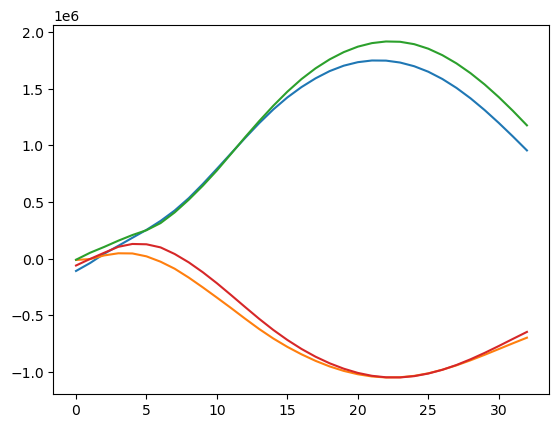

In [61]:
plt.plot(pe_cob_0_list_all[0]-pe_cob_list_all[2])
plt.plot(ke_cob_0_list_all[0]-ke_cob_list_all[2])

plt.plot(pe_cob_0_list_all[1]-pe_cob_list_all[2])
plt.plot(ke_cob_0_list_all[1]-ke_cob_list_all[2])

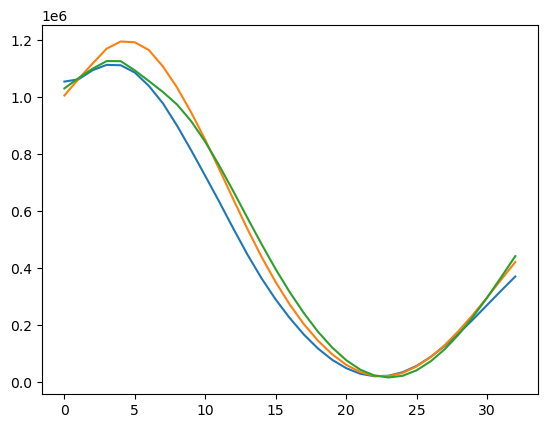

In [62]:
plt.plot(ke_cob_0_list_all.T)

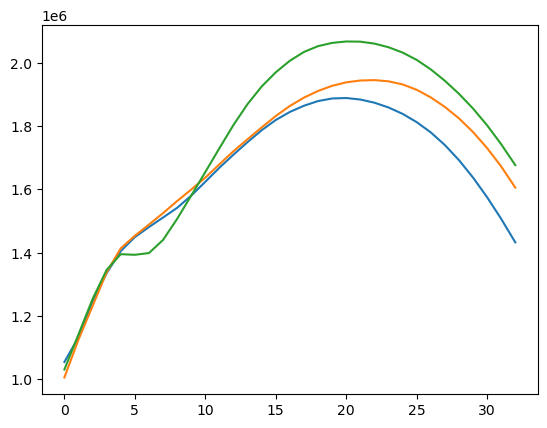

In [69]:
plt.plot(pe_cob_0_list_all[ 0,:] - pe_cob_0_list_all[0,0]+ke_cob_0_list_all[0,:])
plt.plot(pe_cob_0_list_all[ 1,:] - pe_cob_0_list_all[1,0]+ke_cob_0_list_all[1,:])
plt.plot(pe_cob_0_list_all[ 2,:] - pe_cob_0_list_all[2,0]+ke_cob_0_list_all[2,:])

In [133]:
## get potential energy on the cobble slope
itmin = 50
itmax = 95
idt = 1

pe_cob_allcases = []
ke_cob_allcases = []
# for icase in tqdm(range(1)):
for icase in [CASE_NUM]:
    # mom_cob_list = []
    pe_cob_list = []
    ke_cob_list = []
    Case_folder = Case_folder_a[icase]
    fig_folder = fig_folder_a[icase]
    print(Case_folder,fig_folder)
    for i in tqdm(range(itmin,itmax+idt,idt)):
        data = pv.read(f'{Case_folder}PART_{i:05d}.vtp')

        x = data.points[:,0]
        y = data.points[:,1]
        z = data.points[:,2]
        pty = data['Part type']
        pid = data['Part id']
        prs  = data['Pressure']
        vel = data['Velocity']
        mask = np.zeros_like(pid, dtype=bool)
        mask[np.isin(pid, pid_mom)] = True

        vel_mom = vel[mask]
        # x_mom = x[mask]
        z_mom = z[mask]
        mom_cob = np.sum(0.5*(vel_mom[:,0]**2 + vel_mom[:,1]**2 + vel_mom[:,2]**2))
        pe_cob = np.sum(9.81*(z_mom-1.53))
        zc_cob = np.mean(z_mom-1.53)
        pe_cob_list.append(pe_cob)
        ke_cob_list.append(mom_cob)
        # zc_cob_list.append(zc_cob)
        # print(f"Potential energy at x>{x_cob}: {pe_cob}")
    pe_cob_allcases.append(np.array(pe_cob_list))
    ke_cob_allcases.append(np.array(ke_cob_list))
    # zc_cob_allcases.append(np.array(zc_cob_list))

np.save(f'{fig_folder}pe_cob_allcases_front_tip.npy', pe_cob_allcases)
np.save(f'{fig_folder}ke_cob_allcases_front_tip.npy', ke_cob_allcases)


~/work/gpusph/spheric2022_gpusph/matrix_tests/mywaveroughtank_v5_c_slope1_pamp2.0_case2/data/ figure_matrix_slope1_pamp2.0_case2/


100%|██████████| 46/46 [02:57<00:00,  3.87s/it]


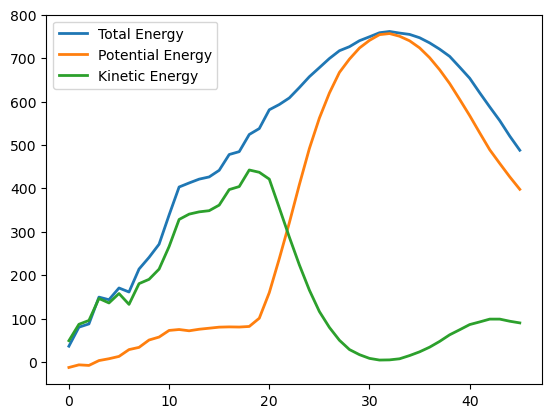

In [183]:
ke_cob_allcases_00 = np.load(f'ke_cob_allcases_front_tip_toe0.npy')
pe_cob_allcases_00 = np.load(f'pe_cob_allcases_front_tip_toe0.npy')

E_total_00 = ke_cob_allcases_00 + pe_cob_allcases_00

plt.plot(E_total_00.T,label='Total Energy',linewidth=2)
plt.plot(pe_cob_allcases_00.T,label='Potential Energy', linewidth=2)
plt.plot(ke_cob_allcases_00.T,label='Kinetic Energy', linewidth=2)
plt.legend()

In [4]:
ke_cob_allcases0 = np.load(f'figure_matrix_slope1_pamp1.5_case0/ke_cob_allcases_front_tip.npy')
pe_cob_allcases0 = np.load(f'figure_matrix_slope1_pamp1.5_case0/pe_cob_allcases_front_tip.npy')
ke_cob_allcases1 = np.load(f'figure_matrix_slope1_pamp1.5_case1/ke_cob_allcases_front_tip.npy')
pe_cob_allcases1 = np.load(f'figure_matrix_slope1_pamp1.5_case1/pe_cob_allcases_front_tip.npy')
ke_cob_allcases2 = np.load(f'figure_matrix_slope1_pamp1.5_case2/ke_cob_allcases_front_tip.npy')
pe_cob_allcases2 = np.load(f'figure_matrix_slope1_pamp1.5_case2/pe_cob_allcases_front_tip.npy')

In [135]:
ke_cob_pamp2_0 = np.load(f'figure_matrix_slope1_pamp2.0_case0/ke_cob_allcases_front_tip.npy')
pe_cob_pamp2_0 = np.load(f'figure_matrix_slope1_pamp2.0_case0/pe_cob_allcases_front_tip.npy')
ke_cob_pamp2_2 = np.load(f'figure_matrix_slope1_pamp2.0_case2/ke_cob_allcases_front_tip.npy')
pe_cob_pamp2_2 = np.load(f'figure_matrix_slope1_pamp2.0_case2/pe_cob_allcases_front_tip.npy')

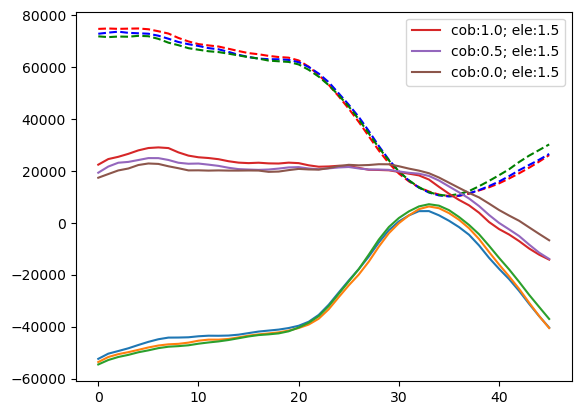

In [205]:
E_total0 = np.array(pe_cob_allcases0) + np.array(ke_cob_allcases0)
E_total1 = np.array(pe_cob_allcases1) + np.array(ke_cob_allcases1)
E_total2 = np.array(pe_cob_allcases2) + np.array(ke_cob_allcases2)

plt.plot(np.array(ke_cob_allcases0).T, '--r')
plt.plot(np.array(pe_cob_allcases0).T)
plt.plot(np.array(ke_cob_allcases1).T,'--b')
plt.plot(np.array(pe_cob_allcases1).T,)
plt.plot(np.array(ke_cob_allcases2).T,'--g')
plt.plot(np.array(pe_cob_allcases2).T,)
plt.plot(E_total0.T, label='cob:1.0; ele:1.5')
plt.plot(E_total1.T, label='cob:0.5; ele:1.5')
plt.plot(E_total2.T, label='cob:0.0; ele:1.5')
plt.legend()


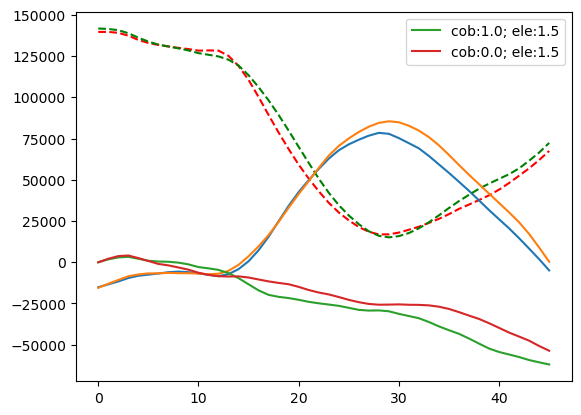

In [137]:
E_total0 = np.array(pe_cob_pamp2_0) + np.array(ke_cob_pamp2_0)
# E_total1 = np.array(pe_cob_allcases1) + np.array(ke_cob_allcases1)
E_total2 = np.array(pe_cob_pamp2_2) + np.array(ke_cob_pamp2_2)

plt.plot(np.array(ke_cob_pamp2_0).T, '--r')
plt.plot(np.array(pe_cob_pamp2_0).T)
# plt.plot(np.array(ke_cob_allcases1).T,'--b')
# plt.plot(np.array(pe_cob_allcases1).T,)
plt.plot(np.array(ke_cob_pamp2_2).T,'--g')
plt.plot(np.array(pe_cob_pamp2_2).T,)
plt.plot(E_total0.T-E_total0[:,0], label='cob:1.0; ele:1.5')
# plt.plot(E_total1.T-E_total1[:,20], label='cob:0.5; ele:1.5')
plt.plot(E_total2.T-E_total2[:,0], label='cob:0.0; ele:1.5')
plt.legend()


# get friction energy....

In [139]:
# dimension of the tank
lx = 96.5
ly = 2
lz = 5.65

dx=0.1
dy=0.1
dz=0.1

from scipy.spatial import cKDTree
def find_spatial_outliers(x, y, z, mad_scale=10):
    coords = np.column_stack((x, y, z))
    tree = cKDTree(coords)

    # k=2 -> [self, nearest-neighbor]
    distances, _ = tree.query(coords, k=2)
    nearest_neighbor_dist = distances[:, 1]

    median_d = np.median(nearest_neighbor_dist)
    mad = np.median(np.abs(nearest_neighbor_dist - median_d))
    threshold = median_d + mad_scale * mad

    outliers = np.where(nearest_neighbor_dist > threshold)[0]
    coords_clean = np.delete(coords, outliers, axis=0)

    return coords_clean, outliers

In [149]:
for icase in range(2,3,1):

    Case_folder = Case_folder_a[icase]
    fig_folder = fig_folder_a[icase]
    print(fig_folder)
    try:
        os.mkdir(fig_folder)
        print(f"Folder '{fig_folder}' created.")
    except FileExistsError:
        print(f"Folder '{fig_folder}' already exists.")
    itmin = 50
    itmax = 90
    idt = 1
    x_grid = np.arange(0, lx + dx, dx)
    y_grid = np.arange(0, ly + dy, dy)
    # y_grid = np.arange(ly/2, ly/2+dy, dy)

    # eta_all = []
    u_all = []
    w_all = []
    # nbins_all = []
    npart_all = []
    # zbottom_all = []

    for i in tqdm(range(itmin,itmax+idt,idt)):
        # print(i)
        data = pv.read(f'{Case_folder}PART_{i:05d}.vtp')
        water_mask = data['Part type'] == 0
        part_water = data.points[water_mask]
        vel_water = data['Velocity'][water_mask]
        x, y, z = part_water[:, 0], part_water[:, 1], part_water[:, 2]

        coords_clean, outliers = find_spatial_outliers(x, y, z, mad_scale=10)
        vel_clean = np.delete(vel_water, outliers, axis=0)
        x1, y1, z1 = coords_clean[:, 0], coords_clean[:, 1], coords_clean[:, 2]
        u1, v1, w1 = vel_clean[:, 0], vel_clean[:, 1], vel_clean[:, 2]

        ua, _, _, _ = binned_statistic_2d(
            x1, y1, u1, statistic='mean', bins=[x_grid, y_grid]
        )
        wa, _, _, _ = binned_statistic_2d(
            x1, y1, w1, statistic='mean', bins=[x_grid, y_grid]
        )
        npart, _, _, _ = binned_statistic_2d(
            x1, y1, None, statistic='count', bins=[x_grid, y_grid]
        )


        # eta_all.append(eta)
        # nbins_all.append(nbins)
        u_all.append(ua)
        w_all.append(wa)
        npart_all.append(npart)
    # eta_all = np.array(eta_all)
    # nbins_all = np.array(nbins_all)
    u_all = np.array(u_all)
    w_all = np.array(w_all)
    npart_all = np.array(npart_all)

    y = np.arange(0,1)
    t = np.arange(12.5,22.5+0.25, 0.25)

    ds_elevation = xr.Dataset(
        {
            "u": (("t", "x_grid", "y"), u_all),
            "w": (("t", "x_grid", "y"), w_all),
            "nparticles": (("t", "x_grid", "y"), npart_all)
        },
        coords={
            "t": t,
            "x_grid": x_grid[0:-1],
            "y_grid": y_grid[0:-1]
        }
    )
    ds_elevation.to_netcdf(f'{fig_folder}/uw_Euler_all_output_v3.nc')
    print(f'Saved to folder:  {fig_folder}')

figure_matrix_slope1_pamp1.5_case2/
Folder 'figure_matrix_slope1_pamp1.5_case2/' already exists.


  0%|          | 0/41 [00:00<?, ?it/s]

100%|██████████| 41/41 [08:18<00:00, 12.16s/it]

Saved to folder:  figure_matrix_slope1_pamp1.5_case2/


In [164]:
for icase in range(0,1,1):

    Case_folder = Case_folder_a[icase]
    fig_folder = fig_folder_a[icase]
    print(fig_folder)
    uw_xr = xr.open_dataset(f'{fig_folder}/uw_Euler_all_output_v3.nc')
    eta_xr = xr.open_dataset(f'{fig_folder}/elev_Euler_all_output_v3.nc')

    

figure_matrix_slope1_pamp1.5_case0/


In [188]:
# Along-slope velocity by vector projection onto a 1:5 slope tangent.
slope_rise = 1.0
slope_run = 5.0
tangent_norm = np.sqrt(slope_run**2 + slope_rise**2)
t_hat_x = slope_run / tangent_norm
t_hat_z = slope_rise / tangent_norm

uw_xr["u_along_slope"] = uw_xr.u * t_hat_x + uw_xr.w * t_hat_z
uw_xr["u_along_slope"].attrs.update(
    long_name="along-slope velocity",
    units="m/s",
    positive="increasing x along a 1:5 upslope tangent",
)

uw_xr.u_along_slope

<xarray.DataArray 'u_along_slope' (t: 41, x_grid: 965, y: 20)> Size: 6MB
array([[[            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan, -7.05515926e-03, -3.25551491e-04, ...,
         -2.58690359e-04,  1.50468395e-03,             nan],
        [            nan,  3.89319144e-04,  1.52468774e-03, ...,
         -2.98869408e-03,  3.05699198e-03,             nan],
        ...,
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]],

       [[            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan, -4.19565986e-04, -1.12296617e-03, ...,
         -2.53691508e-03,  2.80280897e-03,             nan],
        [            nan,  3.71924724e-03, -1.49235310e-03, ...,
         -1.07406437e-03, -2.20614823e-03,             nan],
...
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]],

       [[            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan, -6.45228747e-04, -3.33967104e-03, ...,
          6.50944018e-04, -1.49161141e-03,             nan],
        [            nan, -9.77128795e-04, -1.65198285e-03, ...,
         -7.65341485e-04, -8.11713807e-05,             nan],
        ...,
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]]])
Coordinates:
  * t        (t) float64 328B 12.5 12.75 13.0 13.25 ... 21.75 22.0 22.25 22.5
  * x_grid   (x_grid) float64 8kB 0.0 0.1 0.2 0.3 0.4 ... 96.1 96.2 96.3 96.4
Dimensions without coordinates: y
Attributes:
    long_name:  along-slope velocity
    units:      m/s
    positive:   increasing x along a 1:5 upslope tangent

In [172]:
# get water depth by finding the elevation of the free surface (where nparticles > 0) and subtracting the DEM elevation

x = uw_xr.x_grid.values

b_slope = (x-71.5) * (1.0/5.0) + 1.53

hdepth = np.full_like(uw_xr.x_grid.values, np.nan)
hdepth = eta_xr.elevation.isel(y=10).sel(x_grid=slice(71.5,None)).values - b_slope[71.5<=x]

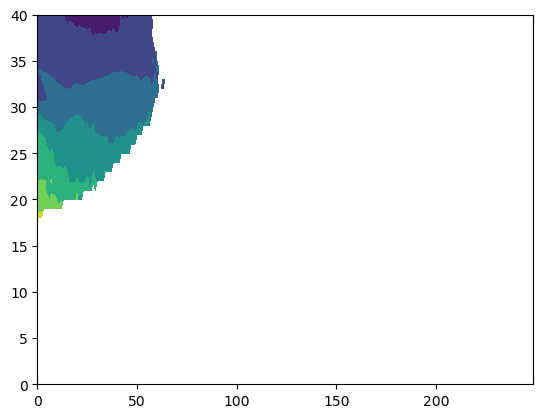

In [ ]:
# get the energy loss rate 

plt.contourf(uw_xr["u_along_slope"].isel(y=10).sel(x_grid=slice(71.5,None)))


In [ ]:
# get friction energy loss

In [189]:
D50 = 0.059
z0 = D50 / 30.0
kappa = 0.41

f_eff = 0.8 * (kappa / (np.log(hdepth / z0)-1))**2

u_along_slope = uw_xr["u_along_slope"].isel(y=10).sel(x_grid=slice(71.5,None)).values
dsk = np.sqrt(0.1**2+(0.1/5)**2)


In [201]:
Df_eff = np.nansum(1/8*f_eff*u_along_slope**3*dsk, axis=1)

Df_eff_sum = np.cumsum(Df_eff)

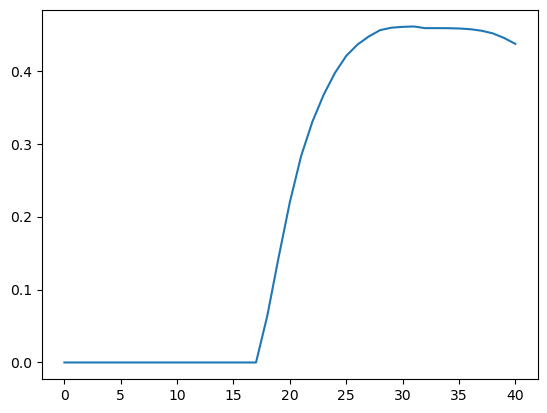

In [202]:
plt.plot(Df_eff_sum)

# get pressure work based on shallow water assumption: W = rho * g * h * u_along_slope

In [87]:
# get minimum KE time TO define the end of energy integration
mom_cob_allcases = np.load('mom_cob_allcases.npy')

# add two columns to mom_cob_allcases, with their elements zeros
mom_cob_allcases_2 = np.hstack((mom_cob_allcases, np.zeros((mom_cob_allcases.shape[0], 2))))

# find the two peaks of the momentum for case 0
from scipy.signal import find_peaks


troughs_in_original_all = []
peaks_all = []
for i in range(mom_cob_allcases_2.shape[0]):
    print(i)
# for i in range(13,14):
    peaks, _ = find_peaks(mom_cob_allcases_2[i], distance=5, width=1, height=10)  # distance parameter to ensure peaks are not too close
    print("Peaks at indices:", peaks)
    peaks_all.append(peaks[0])
    # find the troughs of the momentum for case 0
    if len(peaks) < 2:
        peaks = [0, peaks[0]]
    data_inbetween_peaks = mom_cob_allcases_2[i][peaks[0]:peaks[1]+1]
    troughs, _ = find_peaks(-data_inbetween_peaks, distance=5, width=1, height=np.min(-data_inbetween_peaks))  # find troughs by looking for peaks in the negative of the data
    # get indexes of the troughs in the original data
    troughs_in_original = troughs + peaks[0]
    print("Troughs in original data at indices:", troughs_in_original)
    troughs_in_original_all.append(troughs_in_original)

troughs_in_original_all = np.array(troughs_in_original_all)
peaks_all = np.array(peaks_all)

0
Peaks at indices: [23 41]
Troughs in original data at indices: [33]
1
Peaks at indices: [23 41]
Troughs in original data at indices: [33]
2
Peaks at indices: [23 41]
Troughs in original data at indices: [33]
3
Peaks at indices: [29 40]
Troughs in original data at indices: [37]
4
Peaks at indices: [30 41]
Troughs in original data at indices: [36]
5
Peaks at indices: [30 41]
Troughs in original data at indices: [36]
6
Peaks at indices: [14 36]
Troughs in original data at indices: [27]
7
Peaks at indices: [14 37]
Troughs in original data at indices: [27]
8
Peaks at indices: [15 38]
Troughs in original data at indices: [28]
9
Peaks at indices: [17 35]
Troughs in original data at indices: [26]
10
Peaks at indices: [17 36]
Troughs in original data at indices: [26]
11
Peaks at indices: [18 36]
Troughs in original data at indices: [27]
12
Peaks at indices: [20 34]
Troughs in original data at indices: [30]
13
Peaks at indices: [20 30]
Troughs in original data at indices: [28]
14
Peaks at indi

In [84]:
# get the time when the front approaches the toe 
# based on the elevation variation at x = 71.5

elev_toe = np.zeros((81, 91))
diff_elev_toe = np.zeros((81, 90))
for icase in tqdm(range(0,81,1)):
    ds_eta0 = xr.open_dataset(f"{fig_folder_a[icase]}/elev_Euler_all_output_v3.nc")
    ds_eta00 = xr.open_dataset(f"{fig_folder_a[icase]}/elev_Euler_all_output_v3_0_50.nc")
    elev_toe[icase, :] = xr.concat([ds_eta00, ds_eta0], dim="t").elevation.isel(y=10, x_grid=715).values

diff_elev_toe = np.diff(elev_toe, axis=1)

100%|██████████| 81/81 [00:26<00:00,  3.08it/s]


Case 0: First non-NaN elevation occurs at index 68.
Case 1: First non-NaN elevation occurs at index 68.
Case 2: First non-NaN elevation occurs at index 68.
Case 3: First non-NaN elevation occurs at index 76.
Case 4: First non-NaN elevation occurs at index 76.
Case 5: First non-NaN elevation occurs at index 76.
Case 6: First time index where diff_elev > 0.03 is 59.
Case 7: First time index where diff_elev > 0.03 is 59.
Case 8: First time index where diff_elev > 0.03 is 59.
Case 9: First non-NaN elevation occurs at index 62.
Case 10: First non-NaN elevation occurs at index 62.
Case 11: First non-NaN elevation occurs at index 62.
Case 12: First non-NaN elevation occurs at index 66.
Case 13: First non-NaN elevation occurs at index 66.
Case 14: First non-NaN elevation occurs at index 66.
Case 15: First time index where diff_elev > 0.03 is 54.
Case 16: First time index where diff_elev > 0.03 is 54.
Case 17: First time index where diff_elev > 0.03 is 54.
Case 18: First non-NaN elevation occur

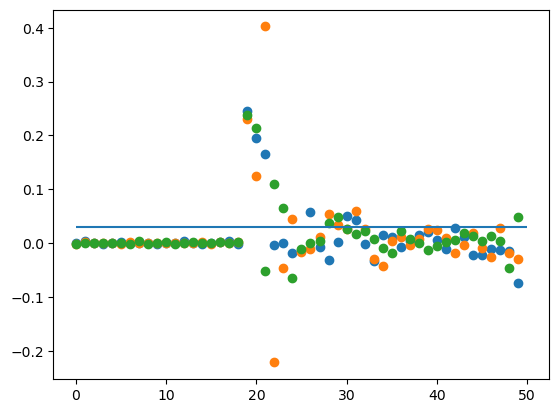

In [85]:
time_toe_all = []

for icase in range(81):

    elev_0 = elev_toe[icase, 0]
    if np.isnan(elev_0):
        # print(f"Case {icase}: Initial elevation is NaN.")
        elev_t = ~np.isnan(elev_toe[icase, :])
        time_toe = np.where(elev_t)[0][0]
        print(f"Case {icase}: First non-NaN elevation occurs at index {time_toe}.")
    else:
        # print(f"Case {icase}: Initial elevation is {elev_0}.")
        delev_t = diff_elev_toe[icase, 40:]
        time_toe = np.where(delev_t > 0.03)[0][0]+40
        print(f"Case {icase}: First time index where diff_elev > 0.03 is {time_toe}.")
    time_toe_all.append(time_toe)

itt=6
plt.plot(diff_elev_toe[itt:itt+3, 40:].T,'o')
# plt.ylim(-0.1, 0.1)
plt.hlines(0.03, 0,50, )



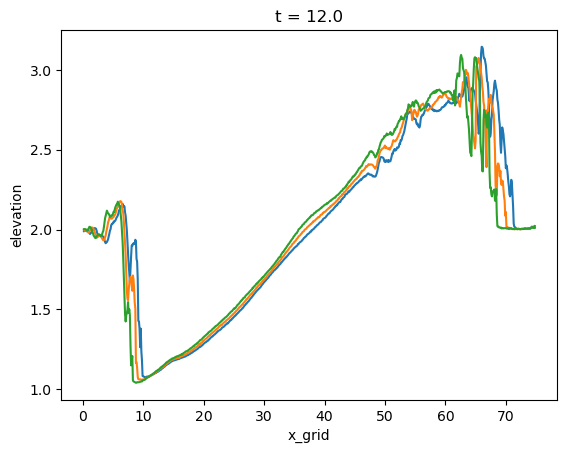

In [79]:
ds_eta0.isel(y=10, t=0).elevation.plot()
ds_eta00.isel(y=10, t=49).elevation.plot()
ds_eta00.isel(y=10, t=48).elevation.plot()

In [9]:
# CASE_NUM=[0,1,2]
#CASE_NUM=[3,4,5]
CASE_NUM=range(81)

In [91]:
xend1 = 35
xend2 = 95
zend1 = -0.5
zend2 = 5.5
def analyze_cob_energy_snapshot(Case_folder, i, x_cob, x_cob2, ref_step):
    data = pv.read(f'{Case_folder}PART_{i:05d}.vtp')

    x = data.points[:, 0]
    y = data.points[:, 1]
    z = data.points[:, 2]
    pty = data['Part type']
    pid = data['Part id']
    prs = data['Pressure']
    vel = data['Velocity']
    # mass = data['Mass']

    # mask = (y >= -0.2) & (y <= 2.23) & (pty == 0) & (x >= xend1) & (x <= xend2) & (z >= zend1) & (z <= zend2)
    mask_wall = (y >= 0.95) & (y <= 1.05) & (pty == 1) & (x >= xend1) & (x <= xend2) & (z >= zend1) & (z <= zend2)
    mask_mom = (y >= 0.95) & (y <= 1.05) & (pty == 0) & (x >= x_cob)
    mask2_mom = (y >= 0.95) & (y <= 1.05) & (pty == 0) & (x >= x_cob2)& (x < x_cob)

    vel_mom = vel[mask_mom]
    x_mom = x[mask_mom]
    z_mom = z[mask_mom]
    pid_mom = pid[mask_mom]
    pid2_mom = pid[mask2_mom]
    mom_cob = np.sum(0.5 * (vel_mom[:, 0] ** 2 + vel_mom[:, 1] ** 2 + vel_mom[:, 2] ** 2))
    pe_cob = np.sum(9.81 * (z_mom - 1.7))

    data2 = pv.read(f'{Case_folder}PART_{ref_step:05d}.vtp')
    pid2 = data2['Part id']
    mask2 = np.zeros_like(pid2, dtype=bool)
    mask3 = np.zeros_like(pid2, dtype=bool)
    # pid_mom is a subset array; use membership test instead of direct == comparison
    mask2[np.isin(pid2, pid_mom)] = True
    mask3[np.isin(pid2, pid2_mom)] = True

    vel2 = data2['Velocity'][mask2]
    x2 = data2.points[:, 0][mask2]
    z2 = data2.points[:, 2][mask2]
    mom_cob_0 = np.sum(0.5 * (vel2[:, 0] ** 2 + vel2[:, 1] ** 2 + vel2[:, 2] ** 2))
    pe_cob_0 = np.sum(9.81 * (data2.points[:, 2][mask2] - 1.7))
    vel3 = data2['Velocity'][mask3]
    x3 = data2.points[:, 0][mask3]
    z3 = data2.points[:, 2][mask3]

    # xsec = x[mask]
    # ysec = y[mask]
    # zsec = z[mask]
    # pidsec = pid[mask]
    # prssec = prs[mask]
    xsec_wall = x[mask_wall]
    ysec_wall = y[mask_wall]
    zsec_wall = z[mask_wall]

    return {
        'pid_mom': pid_mom,
        'mom_cob': mom_cob,
        'pe_cob': pe_cob,
        'mom_cob_0': mom_cob_0,
        'pe_cob_0': pe_cob_0,
        'vel2': vel2,
        'x2': x2,
        'z2': z2,
        'vel3': vel3,
        'x3': x3,
        'z3': z3,
        'xsec_wall': xsec_wall,
        'zsec_wall': zsec_wall,
    }

idt = 1

ke_cob_list_cases = []
pe_cob_list_cases = []
w_bnd_list_cases = []
u_cube1_list_cases = []
u_cube2_list_cases = []
u_mean_list_cases = []
for icase in CASE_NUM:
    t_runup = troughs_in_original_all[icase][0]
    itmin = time_toe_all[icase]
    # itmin = t_runup - 24 +50
    itmax = t_runup +50
    Case_folder = Case_folder_a[icase]
    fig_folder = fig_folder_a[icase]
    print(Case_folder, fig_folder)
    try:
        os.mkdir(fig_folder)
        print(f"Folder '{fig_folder}' created.")
    except FileExistsError:
        print(f"Folder '{fig_folder}' already exists.")

    ke_cob_list = []
    pe_cob_list = []
    w_bnd_list = []
    u_cube1_list = []
    u_cube2_list = []
    u_mean_list = []
    print(itmin, itmax)
    for i in tqdm(range(itmin, itmax + idt, idt)):
        # fig, ax = plt.subplots(figsize=(12, 6))
        # print(i)
        x_cob = 71
        x_cob2 = 35
        # x_cob = 77
        # x_cob2 = 71.5
        ref_step = i

        result = analyze_cob_energy_snapshot(Case_folder, t_runup+50, x_cob=x_cob, x_cob2=x_cob2, ref_step=ref_step)

        # print(f"Momentum at x>{x_cob}: {result['mom_cob']}")
        # print(f"Potential energy at x>{x_cob}: {result['pe_cob']}")
        # print(f"Momentum at x>{x_cob} at it={ref_step}: {result['mom_cob_0']}")
        # print(f"Potential energy at x>{x_cob} at it={ref_step}: {result['pe_cob_0']}")
        # print(f"Difference in momentum: {result['mom_cob_0'] - result['mom_cob']}")
        # print(f"Difference in potential energy: {result['pe_cob_0'] - result['pe_cob']}")

        ke_cob_list.append(result['mom_cob_0'])
        pe_cob_list.append(result['pe_cob_0'])
        pid_mom = result['pid_mom']

        min_x2 = np.min(result['x2'])
        mask_bnd = result['x2'] < min_x2 + 0.5
        eta_bnd = np.max(result['z2'][mask_bnd])
        bot_bnd = (min_x2-15.5) *(1/40) +.15

        hdepth_bnd = eta_bnd - bot_bnd
        u_bnd = np.mean(result['vel2'][mask_bnd, 0])
        w_p_bnd = 0.5 * 9.81 * hdepth_bnd**2 * u_bnd 
        w_bnd_list.append(w_p_bnd)

        # print(u_bnd,hdepth_bnd)
        mask_slope = result['x2'] > 71.5
        u_slope = np.mean(result['vel2'][mask_slope, 0])
        u_mean_list.append(u_slope)
        u_cube1 = np.mean(u_slope**3)
        u_cube1_list.append(u_cube1)
        u_cube2 = np.mean(result['vel2'][:, 0]**3)
        u_cube2_list.append(u_cube2)

        # mc = ax.scatter(result['x2'], result['z2'], 0.2, c=result['vel2'][:, 0], cmap='Reds', vmin=0, vmax=4)
        # cmb = plt.colorbar(mc, ax=ax, label='Toe Velocity (m/s)')
        
        # ax.scatter(result['xsec_wall'], result['zsec_wall'], 0.2, 'grey')
        # ax.set_xlim(xend1, xend2)
        # ax.set_ylim(zend1, zend2)
        # if slope_case_a[icase] == 1:
        #     ax.plot(x_dem1, dem_data1[101, 1:], 'k--')
        # elif slope_case_a[icase] == 2:
        #     ax.plot(x_dem2, dem_data2[101, 1:], 'k--')
        # elif slope_case_a[icase] == 3:
        #     ax.plot(x_dem3, dem_data3[101, 1:], 'k--')

        # print(f"Estimated water surface elevation at the boundary: {eta_bnd}")
        # ax.scatter(result['x2'][mask_bnd], result['z2'][mask_bnd], c='g', s=0.2)
        # ax.plot([min_x2, min_x2], [bot_bnd, eta_bnd], 'c')
        # ax.hlines(eta_bnd,min_x2-0.5, min_x2+0.5, colors='k', )

        # os.makedirs(f"{fig_folder}/chunk_selection_bnd_xcob71", exist_ok=True)
        # fig.savefig(f"{fig_folder}/chunk_selection_bnd_xcob71/time_{i}.png", dpi=300, bbox_inches="tight")
        # plt.close()
    ke_cob_list_cases.append(ke_cob_list)
    pe_cob_list_cases.append(pe_cob_list)
    w_bnd_list_cases.append(w_bnd_list)
    u_cube1_list_cases.append(u_cube1_list)
    u_cube2_list_cases.append(u_cube2_list)
    u_mean_list_cases.append(u_mean_list)


~/work/gpusph/spheric2022_gpusph/matrix_tests/mywaveroughtank_v5_c_slope1_pamp1.5_case0/data/ figure_matrix_slope1_pamp1.5_case0/
Folder 'figure_matrix_slope1_pamp1.5_case0/' already exists.
68 83


  0%|          | 0/16 [00:00<?, ?it/s]

100%|██████████| 16/16 [01:07<00:00,  4.24s/it]


~/work/gpusph/spheric2022_gpusph/matrix_tests/mywaveroughtank_v5_c_slope1_pamp1.5_case1/data/ figure_matrix_slope1_pamp1.5_case1/
Folder 'figure_matrix_slope1_pamp1.5_case1/' already exists.
68 83


100%|██████████| 16/16 [00:25<00:00,  1.56s/it]


...

100%|██████████| 25/25 [03:11<00:00,  7.67s/it]


~/work/gpusph/spheric2022_gpusph/matrix_tests/mywaveroughtank_v5_c_slope3_pamp2.5_case7/data/ figure_matrix_slope3_pamp2.5_case7/
Folder 'figure_matrix_slope3_pamp2.5_case7/' already exists.
50 75


100%|██████████| 26/26 [03:04<00:00,  7.09s/it]


~/work/gpusph/spheric2022_gpusph/matrix_tests/mywaveroughtank_v5_c_slope3_pamp2.5_case8/data/ figure_matrix_slope3_pamp2.5_case8/
Folder 'figure_matrix_slope3_pamp2.5_case8/' already exists.
50 76


100%|██████████| 27/27 [03:06<00:00,  6.92s/it]


In [93]:
# version v2 is extended to 24 steps before the runup 
# version v3 is using the time when the front reaches the toe as the start of the energy integration, instead of 24 steps before the runup

ke_cob_list_cases = np.asarray(ke_cob_list_cases, dtype=object)
pe_cob_list_cases = np.asarray(pe_cob_list_cases, dtype=object)
w_bnd_list_cases = np.asarray(w_bnd_list_cases, dtype=object)
u_cube1_list_cases = np.asarray(u_cube1_list_cases, dtype=object)
u_cube2_list_cases = np.asarray(u_cube2_list_cases, dtype=object)
u_mean_list_cases = np.asarray(u_mean_list_cases, dtype=object)

np.save('ke_cob_list_cases_cob71_v3.npy', ke_cob_list_cases, allow_pickle=True)
np.save('pe_cob_list_cases_cob71_v3.npy', pe_cob_list_cases, allow_pickle=True)
np.save('w_bnd_list_cases_cob71_v3.npy', w_bnd_list_cases, allow_pickle=True)
np.save('u_cube1_list_cases_cob71_v3.npy', u_cube1_list_cases, allow_pickle=True)
np.save('u_cube2_list_cases_cob71_v3.npy', u_cube2_list_cases, allow_pickle=True)
np.save('u_mean_list_cases_cob71_v3.npy', u_mean_list_cases, allow_pickle=True)

In [4]:
# ke_cob_list_cases = np.load('ke_cob_list_cases.npy')
# pe_cob_list_cases = np.load('pe_cob_list_cases.npy')
# w_bnd_list_cases = np.load('w_bnd_list_cases.npy')
# u_cube1_list_cases = np.load('u_cube1_list_cases.npy')
# u_cube2_list_cases = np.load('u_cube2_list_cases.npy')
# u_mean_list_cases = np.load('u_mean_list_cases.npy')

ke_cob_list_cases = np.load('ke_cob_list_cases_cob71_v3.npy', allow_pickle=True)
pe_cob_list_cases = np.load('pe_cob_list_cases_cob71_v3.npy', allow_pickle=True)
w_bnd_list_cases = np.load('w_bnd_list_cases_cob71_v3.npy', allow_pickle=True)
u_cube1_list_cases = np.load('u_cube1_list_cases_cob71_v3.npy', allow_pickle=True)
u_cube2_list_cases = np.load('u_cube2_list_cases_cob71_v3.npy', allow_pickle=True)
u_mean_list_cases = np.load('u_mean_list_cases_cob71_v3.npy', allow_pickle=True)

22
RMS[d(KE+PE)/dt - W_p] = 0.929166
Relative RMS power error = 64.792%
Correlation(d(KE+PE)/dt, W_p) = 0.845
Final Delta(KE+PE) = 2.3766
Final integral(W_p dt) = 6.77081
Final energy residual = -4.39421
23
RMS[d(KE+PE)/dt - W_p] = 0.576827
Relative RMS power error = 53.271%
Correlation(d(KE+PE)/dt, W_p) = 0.669
Final Delta(KE+PE) = 3.10655
Final integral(W_p dt) = 5.01241
Final energy residual = -1.90586
23
RMS[d(KE+PE)/dt - W_p] = 0.772661
Relative RMS power error = 57.874%
Correlation(d(KE+PE)/dt, W_p) = 0.812
Final Delta(KE+PE) = 2.96378
Final integral(W_p dt) = 6.26674
Final energy residual = -3.30296


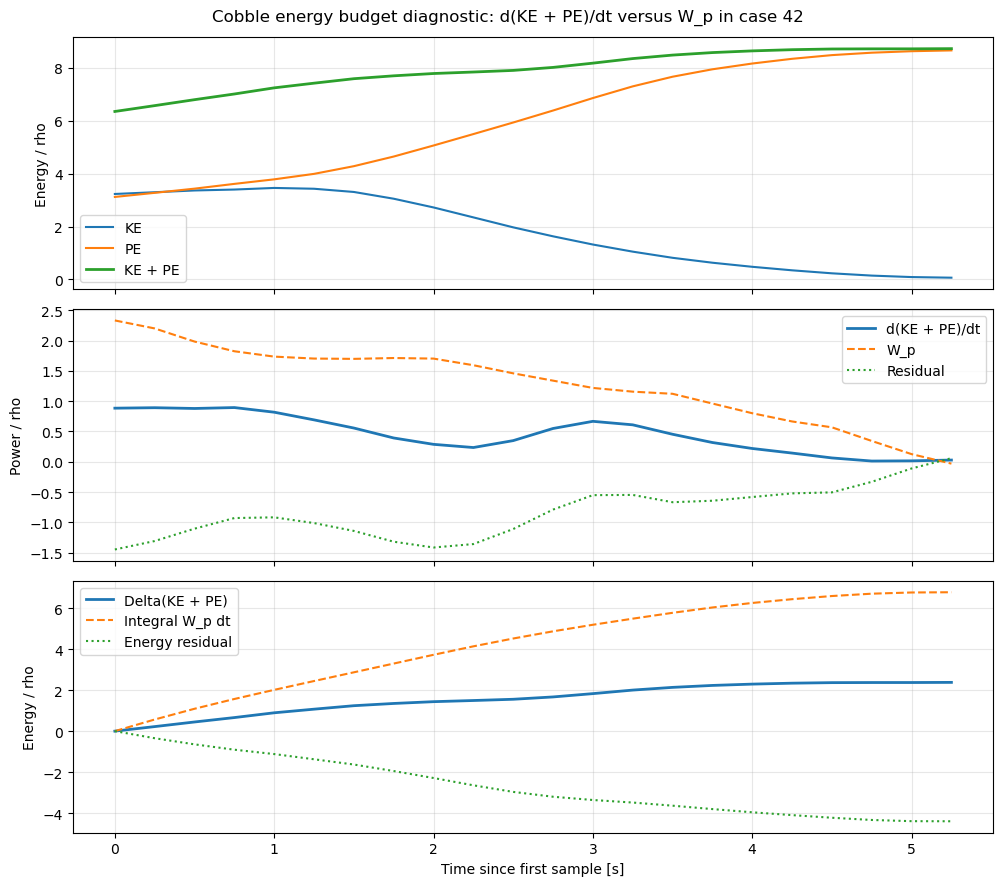

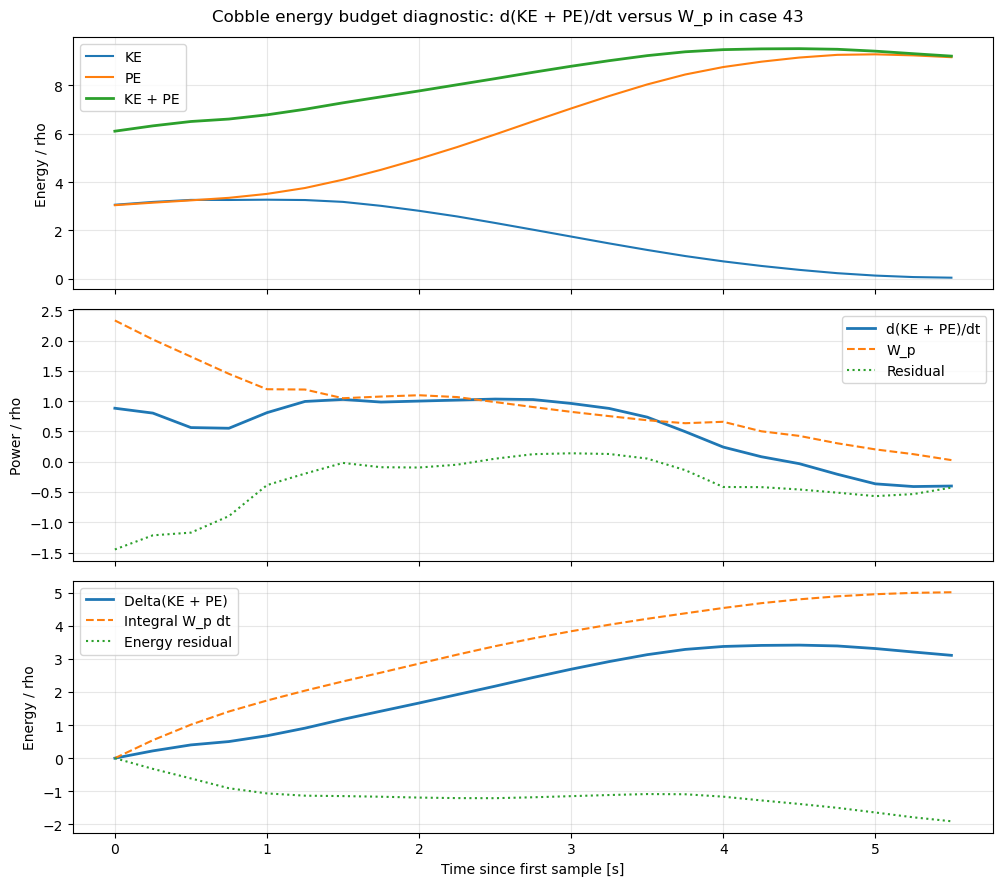

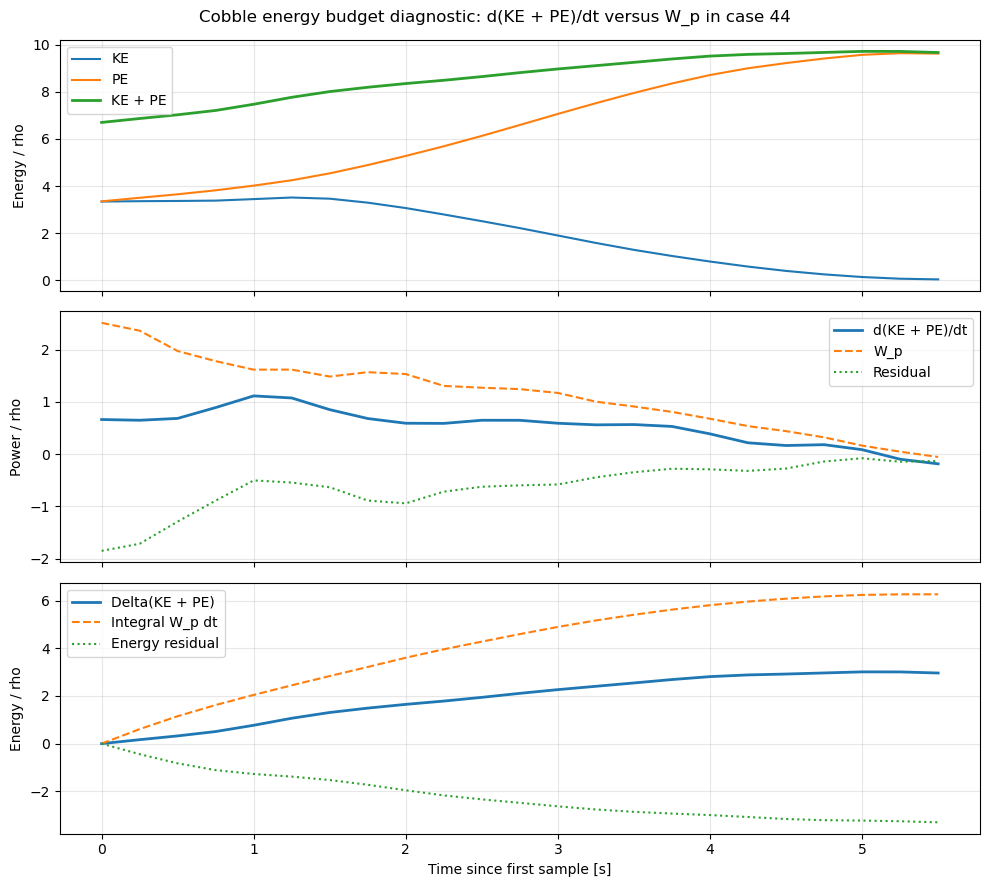

In [43]:
CASE_NUM = range(81)
# Diagnose d(KE + PE)/dt = W_p using the cobble energy and boundary pressure-work lists
# Adjust these two constants if the saved-output interval or particle spacing changes.
dt_diagnostic = 0.25      # physical time between entries in ke_cob_list/pe_cob_list/w_bnd_list [s]
particle_volume = 0.03**3  # particle volume used to convert summed per-particle energy to volume-integrated energy
section_width = 0.1

energy_change_all = []
residual_energy_all = []
wp_integral_all = []
energy_total_all = []
# for icase in range(len(CASE_NUM)):
for icase in range(42,45):
    ke_cob_list = ke_cob_list_cases[icase]
    pe_cob_list = pe_cob_list_cases[icase]
    w_bnd_list = w_bnd_list_cases[icase]
    ke = np.asarray(ke_cob_list, dtype=float) * particle_volume
    pe = np.asarray(pe_cob_list, dtype=float) * particle_volume
    wp = np.asarray(w_bnd_list, dtype=float) * section_width

    n = min(len(ke), len(pe), len(wp))
    print(n)
    if n < 2:
        raise ValueError("Need at least two samples in ke_cob_list, pe_cob_list, and w_bnd_list.")
    if len({len(ke), len(pe), len(wp)}) != 1:
        print(f"Trimming to common length n={n}: KE={len(ke)}, PE={len(pe)}, W_p={len(wp)}")

    ke = ke[:n]
    pe = pe[:n]
    wp = wp[:n]
    time_budget = np.arange(n) * dt_diagnostic

    energy_total = ke + pe
    denergy_dt = np.gradient(energy_total, dt_diagnostic, edge_order=1 if n > 2 else 1)

    wp_integral = np.zeros_like(wp)
    wp_integral[1:] = np.cumsum(0.5 * (wp[:-1] + wp[1:]) * dt_diagnostic)
    energy_change = energy_total - energy_total[0]
    residual_power = denergy_dt - wp
    residual_energy = energy_change - wp_integral
    energy_total_all.append(energy_total)
    energy_change_all.append(energy_change)
    residual_energy_all.append(residual_energy)
    wp_integral_all.append(wp_integral)

    rms_power_error = np.sqrt(np.nanmean(residual_power**2))
    rms_wp = np.sqrt(np.nanmean(wp**2))
    relative_power_error = rms_power_error / rms_wp if rms_wp > 0 else np.nan
    corr_power = np.corrcoef(denergy_dt, wp)[0, 1] if n > 2 else np.nan

    print(f"RMS[d(KE+PE)/dt - W_p] = {rms_power_error:.6g}")
    print(f"Relative RMS power error = {relative_power_error:.3%}")
    print(f"Correlation(d(KE+PE)/dt, W_p) = {corr_power:.3f}")
    print(f"Final Delta(KE+PE) = {energy_change[-1]:.6g}")
    print(f"Final integral(W_p dt) = {wp_integral[-1]:.6g}")
    print(f"Final energy residual = {residual_energy[-1]:.6g}")

    fig, ax = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

    ax[0].plot(time_budget, ke, label="KE")
    ax[0].plot(time_budget, pe, label="PE")
    ax[0].plot(time_budget, energy_total, label="KE + PE", linewidth=2)
    ax[0].set_ylabel("Energy / rho")
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    ax[1].plot(time_budget, denergy_dt, label="d(KE + PE)/dt", linewidth=2)
    ax[1].plot(time_budget, wp, "--", label="W_p")
    ax[1].plot(time_budget, residual_power, ":", label="Residual")
    ax[1].set_ylabel("Power / rho")
    ax[1].legend()
    ax[1].grid(True, alpha=0.3)

    ax[2].plot(time_budget, energy_change, label="Delta(KE + PE)", linewidth=2)
    ax[2].plot(time_budget, wp_integral, "--", label="Integral W_p dt")
    ax[2].plot(time_budget, residual_energy, ":", label="Energy residual")
    ax[2].set_xlabel("Time since first sample [s]")
    ax[2].set_ylabel("Energy / rho")
    ax[2].legend()
    ax[2].grid(True, alpha=0.3)

    fig.suptitle(f"Cobble energy budget diagnostic: d(KE + PE)/dt versus W_p in case {icase}")
    fig.tight_layout()


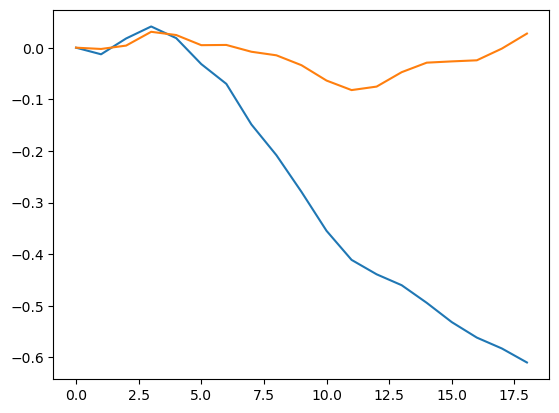

In [6]:
for ig in range(6, 9, 3):
    energy_change_10 = energy_change_all[ig]
    energy_change_05 = energy_change_all[ig+1]
    energy_change_00 = energy_change_all[ig+2]
    residual_energy_10 = residual_energy_all[ig]
    residual_energy_05 = residual_energy_all[ig+1]
    residual_energy_00 = residual_energy_all[ig+2]
    energy_total_10 = energy_total_all[ig]
    energy_total_05 = energy_total_all[ig+1]
    energy_total_00 = energy_total_all[ig+2]

    kmin = np.min((len(energy_change_10), len(energy_change_05), len(energy_change_00)))

    energy_diff_05 = energy_change_05[:kmin] - energy_change_00[:kmin]
    energy_diff_10 = energy_change_10[:kmin] - energy_change_00[:kmin]

    residual_diff_05 = residual_energy_05[:kmin] - residual_energy_00[:kmin]
    residual_diff_10 = residual_energy_10[:kmin] - residual_energy_00[:kmin]

    # plt.plot(energy_change_10, label='cob:1.0; ele:1.5')
    # plt.plot(energy_change_05, label='cob:0.5; ele:1.0')
    # plt.plot(energy_change_00, label='cob:0.0; ele:0.5')
    # plt.plot(energy_total_10, '--', label='total: cob:1.0; ele:1.5')
    # plt.plot(energy_total_05, '--', label='total: cob:0.5; ele:1.0')
    # plt.plot(energy_total_00, '--', label='total: cob:0.0; ele:0.5')
    # # plt.plot(residual_energy_10, '--', label='residual: cob:1.0; ele:1.5')
    # # plt.plot(residual_energy_05, '--', label='residual: cob:0.5; ele:1.0')
    # # plt.plot(residual_energy_00, '--', label='residual: cob:0.0; ele:0.5')
    # plt.legend()
    plt.plot(energy_diff_10, label='Delta Energy: cob:1.0; ele:1.5')
    plt.plot(energy_diff_05, label='Delta Energy: cob:0.5; ele:1.0')
    

RMS loss-model residual = 31.2433
Correlation(loss, C*u**3) = 0.143


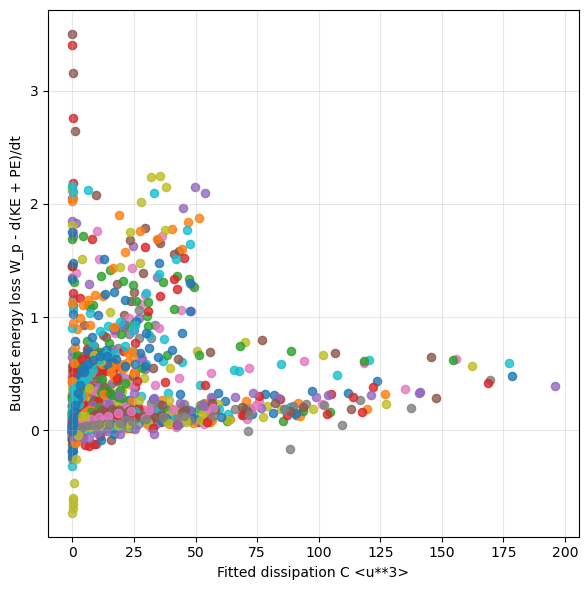

In [44]:
# 1-to-1 test: budget energy loss rate versus a u**3 dissipation model
# Here energy loss is the residual power: D = W_p - d(KE + PE)/dt.
# The fitted model is D_model = C * <u**3>.

dt_diagnostic = 0.25
particle_volume = 0.03**3
section_width = 0.1

loss_all = []
u3_all = []
case_id_all = []
u_mean_all = []
e_total_all = []
ke_total_all = []
pe_total_all = []
erate_all = []

for icase in range(81):
    ke = np.asarray(ke_cob_list_cases[icase], dtype=float) * particle_volume
    pe = np.asarray(pe_cob_list_cases[icase], dtype=float) * particle_volume
    wp = np.asarray(w_bnd_list_cases[icase], dtype=float) * section_width
    u3 = np.asarray(u_cube1_list_cases[icase], dtype=float)
    u_mean = np.asarray(u_cube2_list_cases[icase], dtype=float)

    n = min(len(ke), len(pe), len(wp), len(u3))
    if n < 2:
        continue

    energy_total = ke[:n] + pe[:n]
    denergy_dt = np.gradient(energy_total, dt_diagnostic, edge_order=1 if n > 2 else 1)
    energy_loss_rate = wp[:n] - denergy_dt

    # valid = np.isfinite(energy_loss_rate) & np.isfinite(u3[:n]) & (u3[:n] > 0)
    valid = np.isfinite(energy_loss_rate) & np.isfinite(u3[:n]) 
    loss_all.append(energy_loss_rate[valid])
    u3_all.append(u3[:n][valid])
    erate_all.append(denergy_dt[valid])
    u_mean_all.append(u_mean[:n][valid])
    e_total_all.append(energy_total[:n][valid])
    ke_total_all.append(ke[:n][valid])
    pe_total_all.append(pe[:n][valid])
    case_id_all.append(np.full(np.count_nonzero(valid), icase))

loss_all = np.concatenate(loss_all)
u3_all = np.concatenate(u3_all)
u_mean_all = np.concatenate(u_mean_all)
e_total_all = np.concatenate(e_total_all)
ke_total_all = np.concatenate(ke_total_all)
pe_total_all = np.concatenate(pe_total_all)
case_id_all = np.concatenate(case_id_all)

# Least-squares coefficient for D = C * u**3, forced through the origin.
# coef_u3 = np.sum(u3_all * loss_all) / np.sum(u3_all**2)
loss_model =  u3_all

rms_u3 = np.sqrt(np.nanmean((loss_all - loss_model)**2))
corr_u3 = np.corrcoef(loss_all, loss_model)[0, 1] if len(loss_all) > 2 else np.nan
# print(f"Fitted coefficient C = {coef_u3:.6g}")
print(f"RMS loss-model residual = {rms_u3:.6g}")
print(f"Correlation(loss, C*u**3) = {corr_u3:.3f}")

fig, ax = plt.subplots(figsize=(6, 6))
for icase in np.unique(case_id_all):
    m = case_id_all == icase
    ax.scatter(loss_model[m], loss_all[m], s=35, alpha=0.8, label=f"case {CASE_NUM[icase]}")

lims = [
    np.nanmin([loss_model.min(), loss_all.min()]),
    np.nanmax([loss_model.max(), loss_all.max()]),
]
pad = 0.05 * (lims[1] - lims[0]) if lims[1] > lims[0] else 1.0
lims = [lims[0] - pad, lims[1] + pad]
# ax.plot(lims, lims, "k--", linewidth=1.5, label="1:1")
# ax.set_xlim(lims)
# ax.set_ylim(lims)
# ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Fitted dissipation C <u**3>")
ax.set_ylabel("Budget energy loss W_p - d(KE + PE)/dt")
# ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()


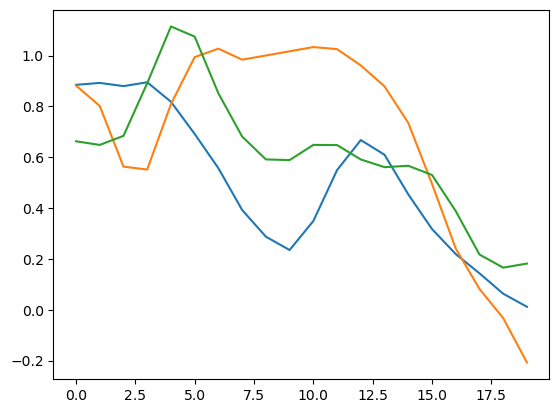

In [ ]:
kmin = np.min((len(case_id_all[case_id_all==15]), len(case_id_all[case_id_all==16]), len(case_id_all[case_id_all==17])))

kmin
# plt.plot(loss_all[case_id_all==42][:kmin])
# plt.plot(loss_all[case_id_all==43][:kmin])
# plt.plot(loss_all[case_id_all==44][:kmin])

plt.plot(erate_all[42][:kmin])
plt.plot(erate_all[43][:kmin])
plt.plot(erate_all[44][:kmin])

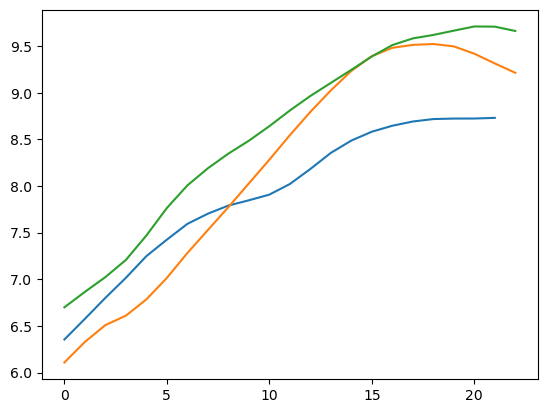

In [42]:
plt.plot(e_total_all[case_id_all==42])
plt.plot(e_total_all[case_id_all==43])
plt.plot(e_total_all[case_id_all==44])

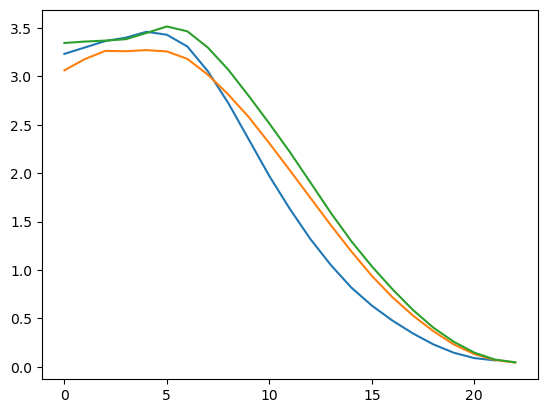

In [45]:
plt.plot(ke_total_all[case_id_all==42])
plt.plot(ke_total_all[case_id_all==43])
plt.plot(ke_total_all[case_id_all==44])

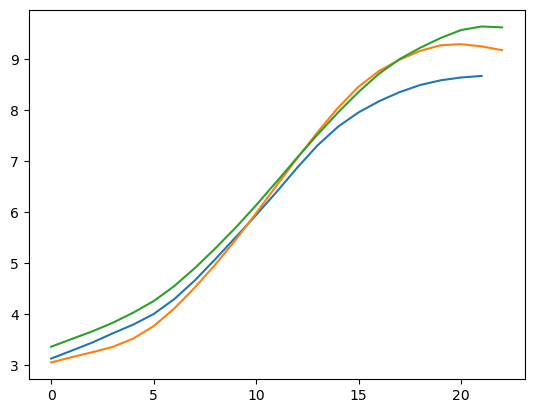

In [46]:
plt.plot(pe_total_all[case_id_all==42])
plt.plot(pe_total_all[case_id_all==43])
plt.plot(pe_total_all[case_id_all==44])

In [9]:
diff_e_loss_05_total = []
diff_e_loss_10_total = []
for ig in range(0, 81, 3):
    kmin = np.min((len(case_id_all[case_id_all==ig]), len(case_id_all[case_id_all==ig+1]), len(case_id_all[case_id_all==ig+2])))
    e_total_10 = e_total_all[case_id_all==ig][:kmin]
    e_total_05 = e_total_all[case_id_all==ig+1][:kmin]
    e_total_00 = e_total_all[case_id_all==ig+2][:kmin]

    # plt.plot(np.arange(kmin)*0.25, e_total_10-e_total_10[0], label='cob:1.0; ele:1.5')
    # plt.plot(np.arange(kmin)*0.25, e_total_05-e_total_05[0], label='cob:0.5; ele:1.0')
    # plt.plot(np.arange(kmin)*0.25, e_total_00-e_total_00[0], label='cob:0.0; ele:0.5')
    # plt.legend()

    e_loss_10 = e_total_10[-1]-e_total_10[0]
    e_loss_05 = e_total_05[-1]-e_total_05[0]
    e_loss_00 = e_total_00[-1]-e_total_00[0]

    diff_e_loss_05 = e_loss_05 - e_loss_00
    diff_e_loss_10 = e_loss_10 - e_loss_00
    diff_e_loss_05_total.append(diff_e_loss_05)
    diff_e_loss_10_total.append(diff_e_loss_10)

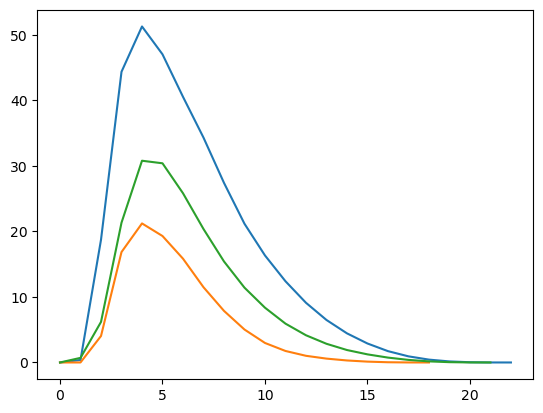

In [10]:

# plt.plot(loss_all[case_id_all==0])
# plt.plot(u3_all[case_id_all==0])
# plt.plot(u3_all[case_id_all==1])
# plt.plot(u3_all[case_id_all==2])
plt.plot(u3_all[case_id_all==51])
plt.plot(u3_all[case_id_all==6])
plt.plot(u3_all[case_id_all==42])
# plt.plot(u3_all[case_id_all==53])
# plt.plot(u3_all[case_id_all==54])

In [46]:
e_total_all = np.asarray(e_total_all, dtype=float)

In [47]:
e_total_all.shape

(1464,)

In [11]:
eps1_sum = np.zeros_like(CASE_NUM, dtype=float)
u3_sum = np.zeros_like(CASE_NUM, dtype=float)
umean_sum = np.zeros_like(CASE_NUM, dtype=float)
for icase in np.unique(case_id_all):
    eps1_sum[icase] = np.sum(loss_all[case_id_all==icase][2:-2] )
    u3_sum[icase] = np.sum(u3_all[case_id_all==icase][2:-2] )
    umean_sum[icase] = np.sum(u_mean_all[case_id_all==icase] )
    # if icase in [6,7,8]:
    #     u3_sum[icase] = np.sum(u3_all[case_id_all==icase][8:-2] )

In [28]:
diff_eps1_05_total = []
diff_eps1_10_total = []
ki = 0
for ig in range(0, 81, 3):

    print(ki, ig)
    eps1_10 = eps1_sum[ig]
    eps1_05 = eps1_sum[ig+1]
    eps1_00 = eps1_sum[ig+2]

    diff_eps1_05 = eps1_05 - eps1_00
    diff_eps1_10 = eps1_10 - eps1_00

    diff_eps1_05_total.append(diff_eps1_05)
    diff_eps1_10_total.append(diff_eps1_10)
    ki += 1

0 0
1 3
2 6
3 9
4 12
5 15
6 18
7 21
8 24
9 27
10 30
11 33
12 36
13 39
14 42
15 45
16 48
17 51
18 54
19 57
20 60
21 63
22 66
23 69
24 72
25 75
26 78


In [20]:
eps1_sum_cob10 = np.concatenate([eps1_sum[0:-1:9], eps1_sum[3:-1:9]])
eps1_sum_cob10_elev1 = np.concatenate([eps1_sum[3:-1:9]])
eps1_sum_cob10_elev2 = np.concatenate([ eps1_sum[0:-1:9]])
eps1_sum_cob10_elev3 = np.concatenate([ eps1_sum[6:-1:9]])

eps1_sum_cob05 = np.concatenate([eps1_sum[1:-1:9], eps1_sum[4:-1:9]])
eps1_sum_cob05_elev1 = np.concatenate([eps1_sum[4:-1:9]])
eps1_sum_cob05_elev2 = np.concatenate([ eps1_sum[1:-1:9]])
eps1_sum_cob05_elev3 = np.concatenate([ eps1_sum[7:-1:9]])
eps1_sum_cob00 = np.concatenate([eps1_sum[2:-1:9], eps1_sum[5:-1:9]])
eps1_sum_cob00_elev3 = np.concatenate([eps1_sum[8:81:9]])
u3_sum_cob10 = np.concatenate([u3_sum[0:-1:9], u3_sum[3:-1:9]])
u3_sum_cob10_elev1 = np.concatenate([u3_sum[3:-1:9]])
u3_sum_cob10_elev2 = np.concatenate([ u3_sum[0:-1:9]])
u3_sum_cob10_elev3 = np.concatenate([ u3_sum[6:-1:9]])
u3_sum_cob05 = np.concatenate([u3_sum[1:-1:9], u3_sum[4:-1:9]])
u3_sum_cob05_elev1 = np.concatenate([u3_sum[4:-1:9]])
u3_sum_cob05_elev2 = np.concatenate([ u3_sum[1:-1:9]])
u3_sum_cob05_elev3 = np.concatenate([ u3_sum[7:-1:9]])
u3_sum_cob00 = np.concatenate([u3_sum[2:-1:9], u3_sum[5:-1:9]])
u3_sum_cob00_elev3 = np.concatenate([u3_sum[8:81:9]])

In [14]:
from scipy.stats import linregress

# Calculate linear correlation coefficient
corr_cob10 = np.corrcoef(eps1_sum_cob10, u3_sum_cob10)[0, 1]
corr_cob05 = np.corrcoef(eps1_sum_cob05, u3_sum_cob05)[0, 1]
corr_cob00 = np.corrcoef(eps1_sum_cob00, u3_sum_cob00)[0, 1]
print(f"Linear correlation coefficient between eps1_cob10_sum and u3_cob10_sum: {corr_cob10:.3f}")
print(f"Linear correlation coefficient between eps1_cob05_sum and u3_cob05_sum: {corr_cob05:.3f}")
print(f"Linear correlation coefficient between eps1_cob00_sum and u3_cob00_sum: {corr_cob00:.3f}")

# Optional: get additional regression statistics
slope10, intercept10, r_value10, p_value, std_err = linregress(u3_sum_cob10, eps1_sum_cob10)
slope05, intercept05, r_value05, p_value, std_err = linregress(u3_sum_cob05, eps1_sum_cob05)
slope00, intercept00, r_value00, p_value, std_err = linregress(u3_sum_cob00, eps1_sum_cob00)
print(f"Slope: {slope10:.6g}")
print(f"R-squared: {r_value10**2:.3f}")
print(f"Slope: {slope05:.6g}")
print(f"R-squared: {r_value05**2:.3f}")
print(f"Slope: {slope00:.6g}")
print(f"R-squared: {r_value00**2:.3f}")


Linear correlation coefficient between eps1_cob10_sum and u3_cob10_sum: 0.923
Linear correlation coefficient between eps1_cob05_sum and u3_cob05_sum: 0.840
Linear correlation coefficient between eps1_cob00_sum and u3_cob00_sum: 0.710
Slope: 0.0147213
R-squared: 0.852
Slope: 0.00790072
R-squared: 0.706
Slope: 0.00294973
R-squared: 0.504


In [21]:

slope10_elev3, intercept10_elev3, r_value10_elev3, p_value10_elev3, std_err10_elev3 = linregress(u3_sum_cob10_elev3, eps1_sum_cob10_elev3)
slope05_elev3, intercept05_elev3, r_value05_elev3, p_value05_elev3, std_err05_elev3 = linregress(u3_sum_cob05_elev3, eps1_sum_cob05_elev3)
slope00_elev3, intercept00_elev3, r_value00_elev3, p_value00_elev3, std_err00_elev3 = linregress(u3_sum_cob00_elev3, eps1_sum_cob00_elev3)

Text(0.5, 0, '<u**3> [m^3/s^3]')

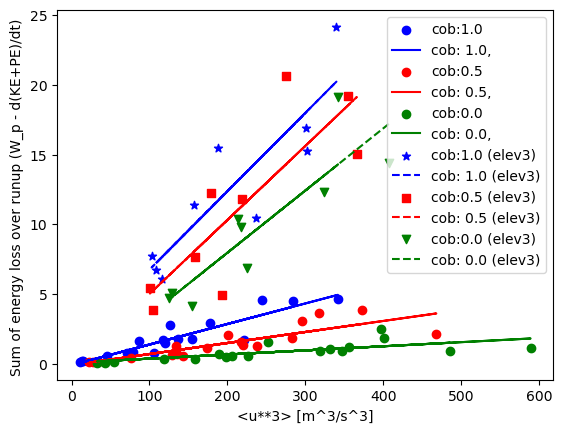

In [22]:


plt.scatter(u3_sum_cob10, eps1_sum_cob10, c='blue', marker='o', label='cob:1.0')
plt.plot(u3_sum_cob10, slope10 * u3_sum_cob10 + intercept10,  color='blue', label=f'cob: 1.0, ')
# plt.scatter(u3_sum_cob10_slope1, eps1_sum_cob10_slope1, c='c', marker='s', label='cob:1.0 (slope1)')
# plt.scatter(u3_sum_cob10_slope2, eps1_sum_cob10_slope2, c='m', marker='s', label='cob:1.0 (slope2)')
plt.scatter(u3_sum_cob05, eps1_sum_cob05, c='red', marker='o', label='cob:0.5')
plt.plot(u3_sum_cob05, slope05 * u3_sum_cob05 + intercept05,  color='red', label=f'cob: 0.5, ')
# plt.scatter(u3_sum_cob05_slope1, eps1_sum_cob05_slope1, c='c', marker='s', label='cob:0.5 (slope1)')
# plt.scatter(u3_sum_cob05_slope2, eps1_sum_cob05_slope2, c='m', marker='s', label='cob:0.5 (slope2)')
plt.scatter(u3_sum_cob00, eps1_sum_cob00, c='green', marker='o', label='cob:0.0')
plt.plot(u3_sum_cob00, slope00 * u3_sum_cob00 + intercept00,  color='green', label=f'cob: 0.0, ')
# plt.scatter(u3_sum[6:-1:9], eps1_sum[6:-1:9], c='blue', marker='*', label='ele:1.5 & cob:1.0')
# plt.scatter(u3_sum[7:-1:9], eps1_sum[7:-1:9], c='red', marker='*', label='ele:0.5 & cob:0.5')
# plt.scatter(u3_sum[8:-1:9], eps1_sum[8:-1:9], c='green', marker='*', label='ele:0.0 & cob:0.0')
plt.scatter(u3_sum_cob10_elev3, eps1_sum_cob10_elev3, c='blue', marker='*', label='cob:1.0 (elev3)')
plt.plot(u3_sum_cob10_elev3, slope10_elev3 * u3_sum_cob10_elev3 + intercept10_elev3,  '--',color='blue', label=f'cob: 1.0 (elev3)')
plt.scatter(u3_sum_cob05_elev3, eps1_sum_cob05_elev3, c='red', marker='s', label='cob:0.5 (elev3)')
plt.plot(u3_sum_cob05_elev3, slope05_elev3 * u3_sum_cob05_elev3 + intercept05_elev3,  '--',color='red', label=f'cob: 0.5 (elev3)')
plt.scatter(u3_sum_cob00_elev3, eps1_sum_cob00_elev3, c='green', marker='v', label='cob:0.0 (elev3)')
plt.plot(u3_sum_cob00_elev3, slope00_elev3 * u3_sum_cob00_elev3 + intercept00_elev3,  '--',color='green', label=f'cob: 0.0 (elev3)')
plt.legend()
plt.ylabel("Sum of energy loss over runup (W_p - d(KE+PE)/dt) ")
plt.xlabel("<u**3> [m^3/s^3]")

# plt.plot(eps1_sum, umean_sum, 'o-')

In [24]:
u3_sum_10 = np.concatenate([u3_sum[0:-1:9], u3_sum[3:-1:9], u3_sum[6:-1:9]])
u3_sum_05 = np.concatenate([u3_sum[1:-1:9], u3_sum[4:-1:9], u3_sum[7:-1:9]])

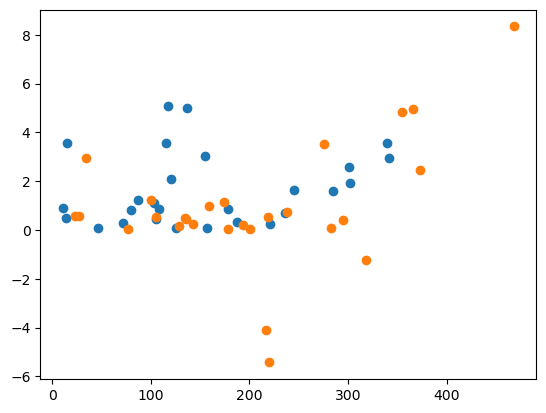

In [25]:
plt.plot(u3_sum_10, diff_eps1_10_total, 'o', label='cob:1.0')
plt.plot(u3_sum_05, diff_eps1_05_total, 'o', label='cob:0.5')

In [27]:
diff_eps1_05_total[14]

-5.4289854607243795

# get froude number, using the mean velocity and water depth

## get the energy loss rate by turbulence model

In [58]:
# fig_folder = fig_folder_a[0]
ds_umean0 = xr.open_dataset(f'{fig_folder_a[51]}/umean_Euler_all_output_v3.nc')
ds_eta0 = xr.open_dataset(f'{fig_folder_a[51]}/elev_Euler_all_output_v3.nc')

# ds_umean6 = xr.open_dataset(f'{fig_folder_a[6]}/umean_Euler_all_output_v3.nc')
# ds_eta6 = xr.open_dataset(f'{fig_folder_a[6]}/elev_Euler_all_output_v3.nc')

# ds_eta3 = xr.open_dataset(f'{fig_folder_a[3]}/elev_Euler_all_output_v3.nc')


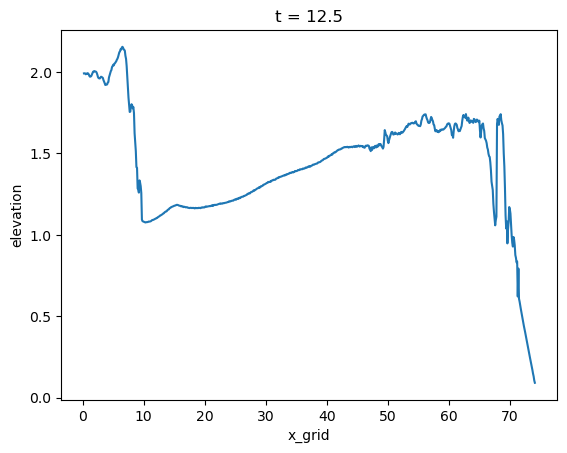

In [60]:
(ds_eta0.elevation.isel(t=t, y=10)-h_bot1).plot()
# (ds_eta6.elevation.isel(t=t, y=10)-h_bot1).plot()

In [74]:
deta_dt0 = np.gradient(ds_eta0.elevation.isel(y=10).values, 0.25, axis=0)
# deta_dt6 = np.gradient(ds_eta6.elevation.isel(y=10).values, 0.25, axis=0)
# deta_dt3 = np.gradient(ds_eta3.elevation.isel(y=10).values, 0.25, axis=0)

t=3, loc_front=[280 281 282 283 284 285 286 287 288 304 305 306 307 308 309 310 311 312
 318 319 320 321 322 323 324 325 326 327 328 329 330 331 332 333 334 335
 336 337 338 339 340 341 342]


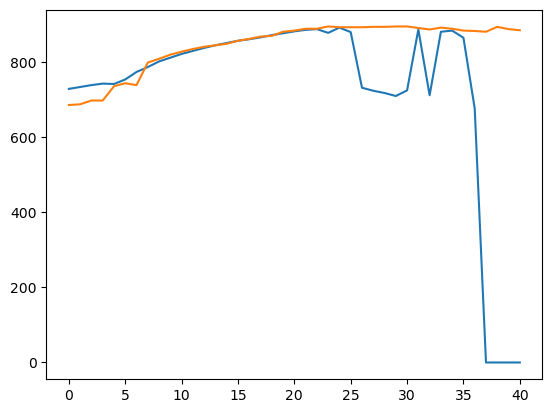

In [83]:
# find the location of maximum deta_dt0 on dimension 1
loc_front = np.zeros(deta_dt0.shape[0], dtype=int)
for t in range(deta_dt0.shape[0]):
    loc = np.where(deta_dt0[t, 400:] >0.025)[0]
    if len(loc) > 0:
        # loc = loc[0] + 400
        loc_front[t] = loc[-1] + 400
    if t==3:
        print(f"t={t}, loc_front={loc}")
plt.plot(loc_front)
loc_front2 = np.array(loc_front)
for t in range(deta_dt0.shape[0]):
    loc_front2[t] = np.where(ds_eta0.elevation.isel(y=10).values[t, 400:] ==np.nanmax(ds_eta0.elevation.isel(y=10).values[t, 400:]))[0][0]+400
plt.plot(loc_front2)

In [20]:

loc_front = np.zeros((81, 41,))
loc_front2 = np.zeros((81, 41, ))

ds_eta_all = []
for icase in tqdm(range(81)):
    ds_eta = xr.open_dataset(f'{fig_folder_a[icase]}/elev_Euler_all_output_v3.nc')

    deta_dt = np.gradient(ds_eta.elevation.isel(y=10).values, 0.25, axis=0)
    for t in range(deta_dt.shape[0]):
        # loc = np.where(deta_dt[t, 400:] < 0.025)[0]
        loc = np.where(deta_dt[t, 400:] >0.025)[0]
        if len(loc) > 0:
            loc_front[icase, t] = loc[-1] + 400
        
        loc_max = np.where(ds_eta.elevation.isel(y=10).values[t, 400:] == 
                          np.nanmax(ds_eta.elevation.isel(y=10).values[t, 400:]))[0]
        if len(loc_max) > 0:
            loc_front2[icase, t] = loc_max[0] + 400


100%|██████████| 81/81 [01:08<00:00,  1.18it/s]


In [17]:
ds_umean0 = xr.open_dataset(f'{fig_folder_a[0]}/umean_Euler_all_output_v3.nc')
h_bot1 = np.interp(ds_umean0.x_grid.values, x_dem1, dem_data1[101, 1:])
h_bot2 = np.interp(ds_umean0.x_grid.values, x_dem2, dem_data2[101, 1:])
h_bot3 = np.interp(ds_umean0.x_grid.values, x_dem3, dem_data3[101, 1:])

In [244]:
ele_case_a[6]

2.0

In [245]:
# plt.plot(loc_front[0])
# plt.plot(loc_front2[0])

eta_f1 = np.zeros((81, 41))
eta_f2 = np.zeros((81, 41))
eta_f3 = np.zeros((81, 41))
for icase in tqdm(range(81)):
    ds_eta = xr.open_dataset(f'{fig_folder_a[icase]}/elev_Euler_all_output_v3.nc')
    for it in range(41):

        elev_f1 = ds_eta.elevation.isel(t=it, y=10).values[loc_front[icase, it].astype(int)]
        if np.isnan(elev_f1):
            elev_f1 = ds_eta.elevation.isel(t=it, y=10).values[loc_front[icase, it].astype(int)-1]
        elev_f2 = ds_eta.elevation.isel(t=it, y=10).values[loc_front2[icase, it].astype(int)]

        eta_f3[icase, it] = np.max((elev_f2-ele_case_a[icase], 0.03))

        if icase<27:
            eta_f1[icase, it] = np.max((elev_f1-h_bot1[loc_front[icase, it].astype(int)], 0.03))
            eta_f2[icase, it] = np.max((elev_f2-h_bot1[loc_front2[icase, it].astype(int)], 0.03))
        elif icase<54:
            eta_f1[icase, it] = np.max((elev_f1-h_bot2[loc_front[icase, it].astype(int)], 0.03))
            eta_f2[icase, it] = np.max((elev_f2-h_bot2[loc_front2[icase, it].astype(int)], 0.03))
        else:
            eta_f1[icase, it] = np.max((elev_f1-h_bot3[loc_front[icase, it].astype(int)], 0.03))
            eta_f2[icase, it] = np.max((elev_f2-h_bot3[loc_front2[icase, it].astype(int)], 0.03))


100%|██████████| 81/81 [00:17<00:00,  4.74it/s]


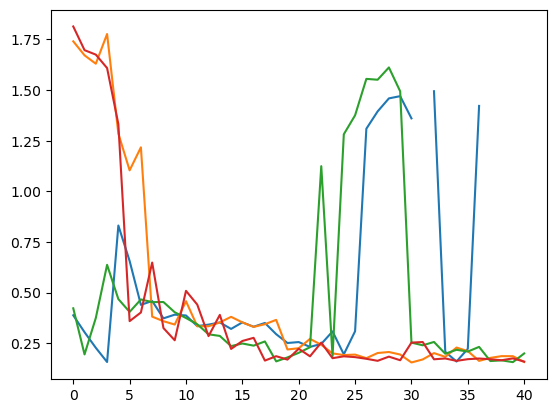

In [22]:
plt.plot(eta_f1[51])
plt.plot(eta_f2[51])
plt.plot(eta_f1[24])
plt.plot(eta_f2[24])

In [248]:
E_turb = (eta_f2-eta_f1)**3/(4*eta_f2*eta_f1)
E_turb2 = (1.5*eta_f3)**3/(4*eta_f2**2)

1 16


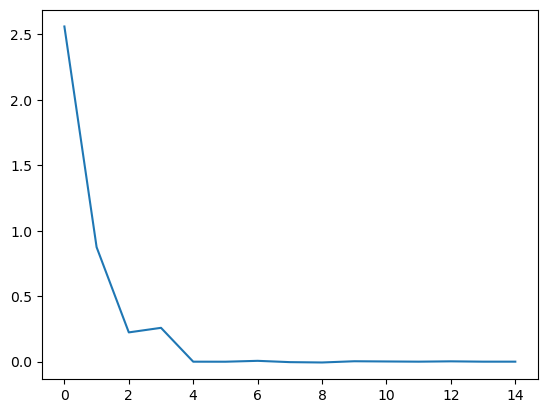

In [30]:
E_turb_sum = np.zeros((81))
for icase in range(81):
    # tstart = troughs_in_original_all[icase][0]-19
    tstart = time_toe_all[icase]-49
    tend = troughs_in_original_all[icase][0]-3

    E_turb_sum[icase] = np.nansum(E_turb[icase, tstart:tend])
    if icase==24:
        plt.plot(E_turb[icase, tstart:tend])
        print(tstart, tend)

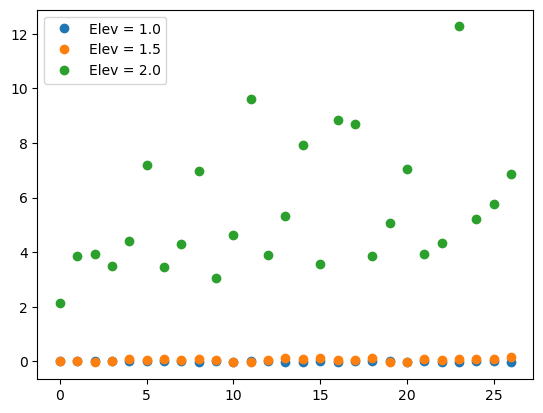

In [75]:
E_turb_sum_cob10_elev1 = np.concatenate([E_turb_sum[3:-1:9], E_turb_sum[4:-1:9], E_turb_sum[5:-1:9]])
E_turb_sum_cob10_elev2 = np.concatenate([ E_turb_sum[0:-1:9], E_turb_sum[1:-1:9], E_turb_sum[2:-1:9]])
E_turb_sum_cob10_elev3 = np.concatenate([ E_turb_sum[6:-1:9], E_turb_sum[7:-1:9], E_turb_sum[8:81:9]])

plt.plot(E_turb_sum_cob10_elev1,'o', label='Elev = 1.0')
plt.plot(E_turb_sum_cob10_elev2,'o', label='Elev = 1.5')
plt.plot(E_turb_sum_cob10_elev3,'o', label='Elev = 2.0')
plt.legend()

In [77]:
u3_sum_elev1 = np.concatenate([u3_sum[3:-1:9], u3_sum[4:-1:9], u3_sum[5:-1:9]])
u3_sum_elev2 = np.concatenate([ u3_sum[0:-1:9], u3_sum[1:-1:9], u3_sum[2:-1:9]])
u3_sum_elev3 = np.concatenate([ u3_sum[6:-1:9], u3_sum[7:-1:9], u3_sum[8:81:9]])

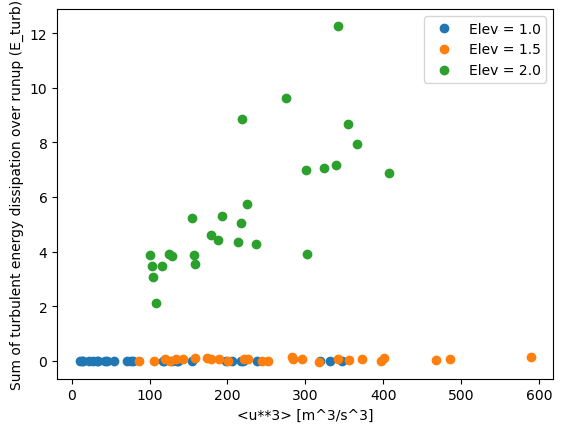

In [78]:
plt.plot(u3_sum_elev1, E_turb_sum_cob10_elev1,'o', label='Elev = 1.0')
plt.plot(u3_sum_elev2, E_turb_sum_cob10_elev2,'o', label='Elev = 1.5')
plt.plot(u3_sum_elev3, E_turb_sum_cob10_elev3,'o', label='Elev = 2.0')
plt.xlabel("<u**3> [m^3/s^3]")
plt.ylabel("Sum of turbulent energy dissipation over runup (E_turb)")
plt.legend()

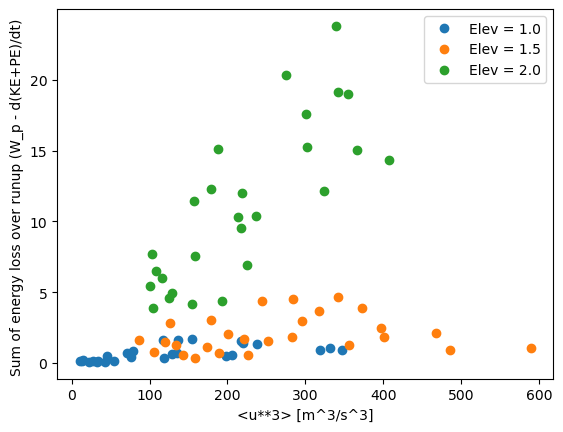

In [254]:
eps1_sum_elev1 = np.concatenate([eps1_sum[3:-1:9], eps1_sum[4:-1:9], eps1_sum[5:-1:9]])
eps1_sum_elev2 = np.concatenate([eps1_sum[0:-1:9], eps1_sum[1:-1:9], eps1_sum[2:-1:9]])
eps1_sum_elev3 = np.concatenate([eps1_sum[6:-1:9], eps1_sum[7:-1:9], eps1_sum[8:81:9]])

plt.plot(u3_sum_elev1, eps1_sum_elev1,'o', label='Elev = 1.0')
plt.plot(u3_sum_elev2, eps1_sum_elev2,'o', label='Elev = 1.5')
plt.plot(u3_sum_elev3, eps1_sum_elev3,'o', label='Elev = 2.0')
plt.xlabel("<u**3> [m^3/s^3]")
plt.ylabel("Sum of energy loss over runup (W_p - d(KE+PE)/dt) ")
plt.legend()

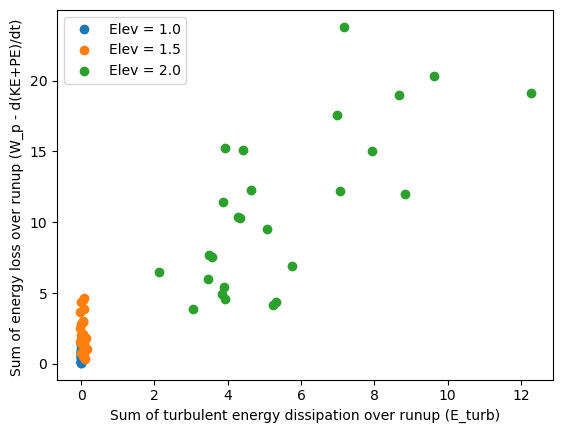

In [118]:
plt.plot(E_turb_sum_cob10_elev1, eps1_sum_elev1,'o', label='Elev = 1.0')
plt.plot(E_turb_sum_cob10_elev2, eps1_sum_elev2,'o', label='Elev = 1.5')
plt.plot(E_turb_sum_cob10_elev3, eps1_sum_elev3,'o', label='Elev = 2.0')
plt.xlabel("Sum of turbulent energy dissipation over runup (E_turb)")
plt.ylabel("Sum of energy loss over runup (W_p - d(KE+PE)/dt) ")
plt.legend()

In [147]:
um = xr.open_dataset(f'{fig_folder_a[51]}/umean_Euler_all_output_v3.nc')

In [35]:
## get control volume of water in the runup region, and compare with the energy loss over runup

x_loc_front2 = ds_eta0.x_grid.values[loc_front2.astype(int)]

u2 = np.zeros((81, 41))
for icase in tqdm(range(81)):
    ds_umean = xr.open_dataset(f'{fig_folder_a[icase]}/umean_Euler_all_output_v3.nc')
    for it in range(41):
        u2[icase, it] = ds_umean.velocity.isel(y=10).values[it, loc_front2[icase, it].astype(int)]

x_loc_front1 = ds_eta0.x_grid.values[loc_front.astype(int)]

c_front = np.zeros((81, 41))
for icase in tqdm(range(81)):
    ds_umean = xr.open_dataset(f'{fig_folder_a[icase]}/umean_Euler_all_output_v3.nc')
    for it in range(41):
        c_front[icase, it] = ds_umean.velocity.isel(y=10).values[it, loc_front[icase, it].astype(int)]
        if np.isnan(c_front[icase, it]):
            c_front[icase, it] = ds_umean.velocity.isel(y=10).values[it, loc_front[icase, it].astype(int)-1]

100%|██████████| 81/81 [00:09<00:00,  8.17it/s]


In [188]:
eta_f2.shape

(81, 41)

10 24
5 23
7 20


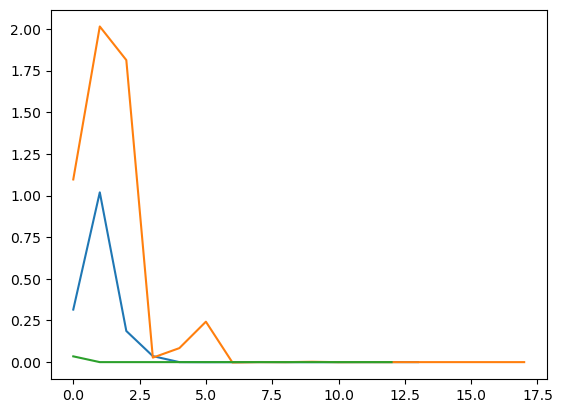

In [282]:
# Qbore = eta_f2 *np.abs(u2-c_front)*0.1

Qbore = eta_f2 *0.1* 0.1
# Qbore2 = eta_f2 *0.1* (1/period_all[:,np.newaxis])
# Qbore2 = eta_f2 *0.1* c_wave_all[:,:]
Qbore2 = eta_f2 *0.1* u2[:,:]
# Qbore2 = eta_f2 *0.1* np.sqrt(eta_f2*9.81)


delta_Ebreak = 9.81* Qbore * E_turb *0.25
delta_Ebreak2 = 9.81* Qbore2 * E_turb *0.25
# delta_Ebreak = 9.81 * E_turb *0.25

E_break_sum = np.zeros((81))
E_break_sum2 = np.zeros((81))
for icase in range(81):
    # tstart = troughs_in_original_all[icase][0]-21
    tstart = time_toe_all[icase]-49
    tend = troughs_in_original_all[icase][0]-3

    E_break_sum[icase] = np.nansum(delta_Ebreak[icase, tstart:tend])
    E_break_sum2[icase] = np.nansum(delta_Ebreak2[icase, tstart:tend])
    if (icase==6)|(icase==43)|(icase==45):
        plt.plot(delta_Ebreak2[icase, tstart:tend])
        print(tstart, tend)

Text(0.5, 0, 'Time step')

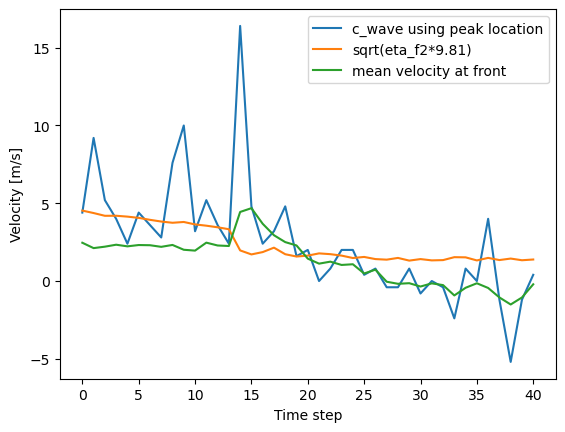

In [262]:
plt.plot(c_wave_all[6], label='c_wave using peak location')
plt.plot(np.sqrt(eta_f2[6]*9.81), label='sqrt(eta_f2*9.81)')
plt.plot(u2[6], label='mean velocity at front')
plt.legend()
plt.ylabel("Velocity [m/s]")
plt.xlabel("Time step")

In [283]:
E_break_sum_elev1 = np.concatenate([ E_break_sum[3:-1:9], E_break_sum[4:-1:9], E_break_sum[5:-1:9]])
E_break_sum_elev2 = np.concatenate([ E_break_sum[0:-1:9], E_break_sum[1:-1:9], E_break_sum[2:-1:9]])
E_break_sum_elev3 = np.concatenate([ E_break_sum[6:-1:9], E_break_sum[7:-1:9], E_break_sum[8:81:9]])
E_break_sum_cob10_elev3 = np.concatenate([ E_break_sum[6:-1:9]])
E_break_sum_cob05_elev3 = np.concatenate([ E_break_sum[7:-1:9]])
E_break_sum_cob00_elev3 = np.concatenate([ E_break_sum[8:81:9]])

E_break_sum_pamp15_elev3 = np.concatenate([ E_break_sum[6:-1:27], E_break_sum[7:-1:27], E_break_sum[8:-1:27]])
E_break_sum_pamp20_elev3 = np.concatenate([ E_break_sum[15:-1:27], E_break_sum[16:-1:27], E_break_sum[17:-1:27]])
E_break_sum_pamp25_elev3 = np.concatenate([ E_break_sum[24:-1:27], E_break_sum[25:-1:27], E_break_sum[26:81:27]])
eps1_sum_pamp15_elev3 = np.concatenate([ eps1_sum[6:-1:27], eps1_sum[7:-1:27], eps1_sum[8:-1:27]])
eps1_sum_pamp20_elev3 = np.concatenate([ eps1_sum[15:-1:27], eps1_sum[16:-1:27], eps1_sum[17:-1:27]])
eps1_sum_pamp25_elev3 = np.concatenate([ eps1_sum[24:-1:27], eps1_sum[25:-1:27], eps1_sum[26:81:27]])

E_break_sum_slope1_elev3 = np.concatenate([ E_break_sum[6:27:9], E_break_sum[7:27:9], E_break_sum[8:27:9]])
E_break_sum_slope2_elev3 = np.concatenate([ E_break_sum[33:54:9], E_break_sum[34:54:9], E_break_sum[35:54:9]])
E_break_sum_slope3_elev3 = np.concatenate([ E_break_sum[60:81:9], E_break_sum[61:81:9], E_break_sum[62:81:9]])
eps1_sum_slope1_elev3 = np.concatenate([ eps1_sum[6:27:9], eps1_sum[7:27:9], eps1_sum[8:27:9]])
eps1_sum_slope2_elev3 = np.concatenate([ eps1_sum[33:54:9], eps1_sum[34:54:9], eps1_sum[35:54:9]])
eps1_sum_slope3_elev3 = np.concatenate([ eps1_sum[60:81:9], eps1_sum[61:81:9], eps1_sum[62:81:9]])


In [284]:
E_break2_sum_elev1 = np.concatenate([ E_break_sum2[3:-1:9], E_break_sum2[4:-1:9], E_break_sum2[5:-1:9]])
E_break2_sum_elev2 = np.concatenate([ E_break_sum2[0:-1:9], E_break_sum2[1:-1:9], E_break_sum2[2:-1:9]])
E_break2_sum_elev3 = np.concatenate([ E_break_sum2[6:-1:9], E_break_sum2[7:-1:9], E_break_sum2[8:81:9]])
E_break2_sum_cob10_elev3 = np.concatenate([ E_break_sum2[6:-1:9]])
E_break2_sum_cob05_elev3 = np.concatenate([ E_break_sum2[7:-1:9]])
E_break2_sum_cob00_elev3 = np.concatenate([ E_break_sum2[8:-1:9]])

E_break2_sum_pamp15_elev3 = np.concatenate([ E_break_sum2[6:-1:27], E_break_sum2[7:-1:27], E_break_sum2[8:-1:27]])
E_break2_sum_pamp20_elev3 = np.concatenate([ E_break_sum2[15:-1:27], E_break_sum2[16:-1:27], E_break_sum2[17:-1:27]])
E_break2_sum_pamp25_elev3 = np.concatenate([ E_break_sum2[24:-1:27], E_break_sum2[25:-1:27], E_break_sum2[26:81:27]])

E_break2_sum_slope1_elev3 = np.concatenate([ E_break_sum2[6:27:9], E_break_sum2[7:27:9], E_break_sum2[8:27:9]])
E_break2_sum_slope2_elev3 = np.concatenate([ E_break_sum2[33:54:9], E_break_sum2[34:54:9], E_break_sum2[35:54:9]])
E_break2_sum_slope3_elev3 = np.concatenate([ E_break_sum2[60:81:9], E_break_sum2[61:81:9], E_break_sum2[62:81:9]])

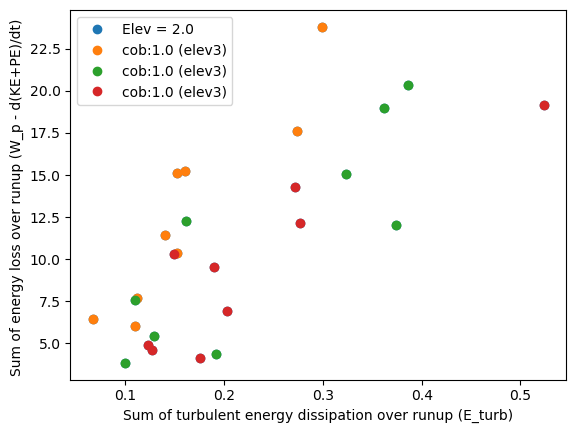

In [255]:
# plt.plot(E_break_sum_elev1, eps1_sum_elev1,'o', label='Elev = 1.0')
# plt.plot(E_break_sum_elev2, eps1_sum_elev2,'o', label='Elev = 1.5')
plt.plot(E_break_sum_elev3, eps1_sum_elev3,'o', label='Elev = 2.0')

plt.plot(E_break_sum_cob10_elev3, eps1_sum_cob10_elev3,'o', label='cob:1.0 (elev3)')
plt.plot(E_break_sum_cob05_elev3, eps1_sum_cob05_elev3,'o', label='cob:1.0 (elev3)')
plt.plot(E_break_sum_cob00_elev3, eps1_sum_cob00_elev3,'o', label='cob:1.0 (elev3)')

plt.xlabel("Sum of turbulent energy dissipation over runup (E_turb)")
plt.ylabel("Sum of energy loss over runup (W_p - d(KE+PE)/dt) ")
plt.legend()

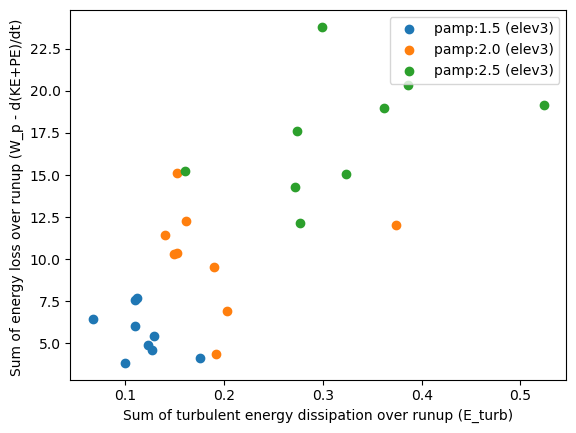

In [229]:
plt.plot(E_break_sum_pamp15_elev3, eps1_sum_pamp15_elev3,'o', label='pamp:1.5 (elev3)')
plt.plot(E_break_sum_pamp20_elev3, eps1_sum_pamp20_elev3,'o', label='pamp:2.0 (elev3)')
plt.plot(E_break_sum_pamp25_elev3, eps1_sum_pamp25_elev3,'o', label='pamp:2.5 (elev3)')

plt.xlabel("Sum of turbulent energy dissipation over runup (E_turb)")
plt.ylabel("Sum of energy loss over runup (W_p - d(KE+PE)/dt) ")
plt.legend()

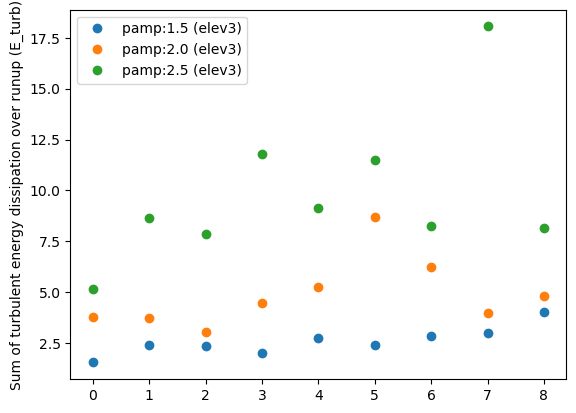

In [269]:
plt.plot(E_break2_sum_pamp15_elev3,'o', label='pamp:1.5 (elev3)')
plt.plot(E_break2_sum_pamp20_elev3,'o', label='pamp:2.0 (elev3)')
plt.plot(E_break2_sum_pamp25_elev3,'o', label='pamp:2.5 (elev3)')

plt.ylabel("Sum of turbulent energy dissipation over runup (E_turb)")
# plt.ylabel("Sum of energy loss over runup (W_p - d(KE+PE)/dt) ")
plt.legend()

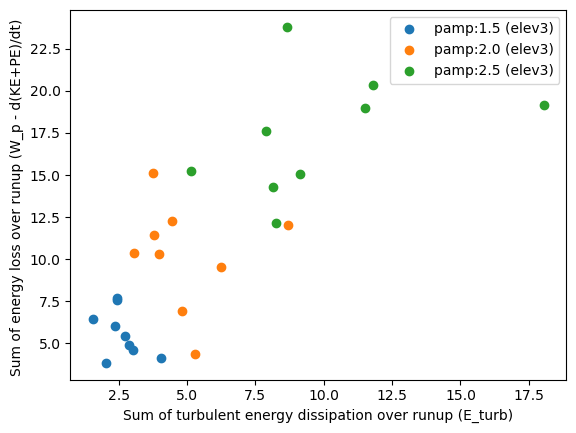

In [270]:
plt.plot(E_break2_sum_pamp15_elev3, eps1_sum_pamp15_elev3,'o', label='pamp:1.5 (elev3)')
plt.plot(E_break2_sum_pamp20_elev3, eps1_sum_pamp20_elev3,'o', label='pamp:2.0 (elev3)')
plt.plot(E_break2_sum_pamp25_elev3, eps1_sum_pamp25_elev3,'o', label='pamp:2.5 (elev3)')

plt.xlabel("Sum of turbulent energy dissipation over runup (E_turb)")
plt.ylabel("Sum of energy loss over runup (W_p - d(KE+PE)/dt) ")
plt.legend()

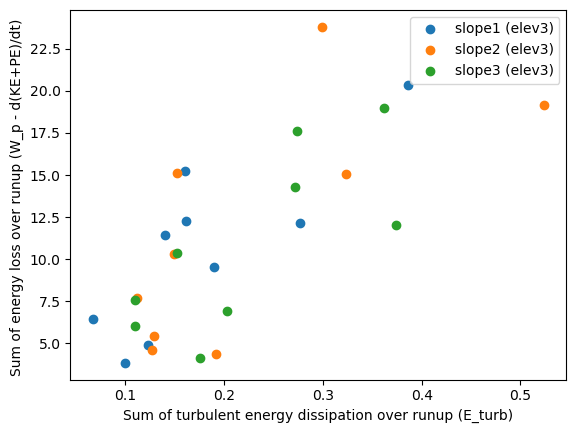

In [48]:
plt.plot(E_break_sum_slope1_elev3, eps1_sum_slope1_elev3,'o', label='slope1 (elev3)')
plt.plot(E_break_sum_slope2_elev3, eps1_sum_slope2_elev3,'o', label='slope2 (elev3)')
plt.plot(E_break_sum_slope3_elev3, eps1_sum_slope3_elev3,'o', label='slope3 (elev3)')

plt.xlabel("Sum of turbulent energy dissipation over runup (E_turb)")
plt.ylabel("Sum of energy loss over runup (W_p - d(KE+PE)/dt) ")
plt.legend()

In [285]:
eps1_sum_subtract_turb = eps1_sum - E_break_sum
eps1_sum_subtract_turb2 = eps1_sum - E_break_sum2

eps1_sum_subtract_turb_cob10 = np.concatenate([eps1_sum_subtract_turb[0:-1:9], eps1_sum_subtract_turb[3:-1:9]])
eps1_sum_subtract_turb_cob10_elev3 = np.concatenate([eps1_sum_subtract_turb[6:-1:9]])
eps1_sum_subtract_turb_cob05 = np.concatenate([eps1_sum_subtract_turb[1:-1:9], eps1_sum_subtract_turb[4:-1:9]])
eps1_sum_subtract_turb_cob05_elev3 = np.concatenate([eps1_sum_subtract_turb[7:-1:9]])
eps1_sum_subtract_turb_cob00 = np.concatenate([eps1_sum_subtract_turb[2:-1:9], eps1_sum_subtract_turb[5:-1:9]])
eps1_sum_subtract_turb_cob00_elev3 = np.concatenate([eps1_sum_subtract_turb[8:-1:9]])

eps1_sum_subtract_turb2_cob10 = np.concatenate([eps1_sum_subtract_turb2[0:-1:9], eps1_sum_subtract_turb2[3:-1:9]])
eps1_sum_subtract_turb2_cob10_elev3 = np.concatenate([eps1_sum_subtract_turb2[6:-1:9]])
eps1_sum_subtract_turb2_cob05 = np.concatenate([eps1_sum_subtract_turb2[1:-1:9], eps1_sum_subtract_turb2[4:-1:9]])
eps1_sum_subtract_turb2_cob05_elev3 = np.concatenate([eps1_sum_subtract_turb2[7:-1:9]])
eps1_sum_subtract_turb2_cob00 = np.concatenate([eps1_sum_subtract_turb2[2:-1:9], eps1_sum_subtract_turb2[5:-1:9]])
eps1_sum_subtract_turb2_cob00_elev3 = np.concatenate([eps1_sum_subtract_turb2[8:-1:9]])


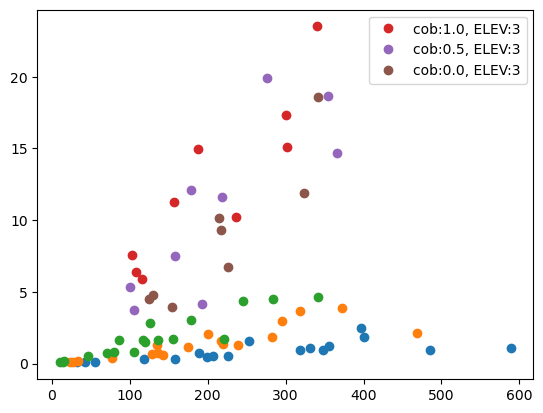

In [212]:
plt.plot(u3_sum_cob00, eps1_sum_subtract_turb_cob00, 'o')
plt.plot(u3_sum_cob05, eps1_sum_subtract_turb_cob05, 'o')
plt.plot(u3_sum_cob10, eps1_sum_subtract_turb_cob10, 'o')
plt.plot(u3_sum_cob10_elev3, eps1_sum_subtract_turb_cob10_elev3, 'o', label='cob:1.0, ELEV:3')
plt.plot(u3_sum_cob05_elev3, eps1_sum_subtract_turb_cob05_elev3, 'o', label='cob:0.5, ELEV:3')
plt.plot(u3_sum_cob00_elev3, eps1_sum_subtract_turb_cob00_elev3, 'o', label='cob:0.0, ELEV:3')
# plt.plot(u3_sum_cob00, eps1_sum_cob00, 'o')
plt.legend()
# plt.plot(u3_sum, eps1_sum, 'o', label='cob:1.0')

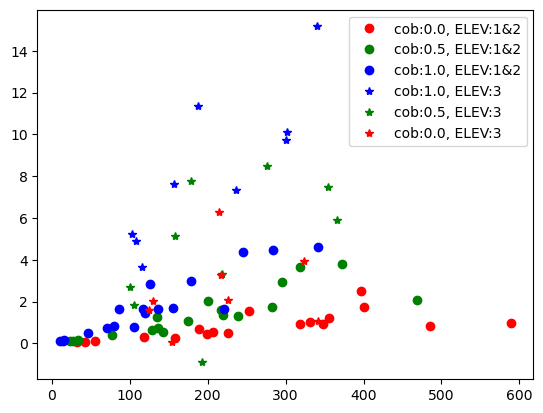

In [237]:
plt.plot(u3_sum_cob00, eps1_sum_subtract_turb2_cob00, 'or', label='cob:0.0, ELEV:1&2')
plt.plot(u3_sum_cob05, eps1_sum_subtract_turb2_cob05, 'og', label='cob:0.5, ELEV:1&2')
plt.plot(u3_sum_cob10, eps1_sum_subtract_turb2_cob10, 'ob', label='cob:1.0, ELEV:1&2')
plt.plot(u3_sum_cob10_elev3, eps1_sum_subtract_turb2_cob10_elev3, '*b', label='cob:1.0, ELEV:3')
plt.plot(u3_sum_cob05_elev3, eps1_sum_subtract_turb2_cob05_elev3, '*g', label='cob:0.5, ELEV:3')
plt.plot(u3_sum_cob00_elev3, eps1_sum_subtract_turb2_cob00_elev3, '*r', label='cob:0.0, ELEV:3')
# plt.plot(u3_sum_cob00, eps1_sum_cob00, 'o')
plt.legend()
# plt.plot(u3_sum, eps1_sum, 'o', label='cob:1.0')
# plt.ylim(-2,10)

In [287]:
slope10_subtract_turb, intercept10_subtract_turb, r_value10_subtract_turb, p_value10_subtract_turb, std_err10_subtract_turb = linregress(u3_sum_cob10_elev3, eps1_sum_subtract_turb_cob10_elev3)
slope05_subtract_turb, intercept05_subtract_turb, r_value05_subtract_turb, p_value05_subtract_turb, std_err05_subtract_turb = linregress(u3_sum_cob05_elev3, eps1_sum_subtract_turb_cob05_elev3)
slope00_subtract_turb, intercept00_subtract_turb, r_value00_subtract_turb, p_value00_subtract_turb, std_err00_subtract_turb = linregress(u3_sum_cob00_elev3, eps1_sum_subtract_turb_cob00_elev3)

slope10_subtract_turb2, intercept10_subtract_turb2, r_value10_subtract_turb2, p_value10_subtract_turb2, std_err10_subtract_turb2 = linregress(u3_sum_cob10_elev3, eps1_sum_subtract_turb2_cob10_elev3)
slope05_subtract_turb2, intercept05_subtract_turb2, r_value05_subtract_turb2, p_value05_subtract_turb2, std_err05_subtract_turb2 = linregress(u3_sum_cob05_elev3, eps1_sum_subtract_turb2_cob05_elev3)
slope00_subtract_turb2, intercept00_subtract_turb2, r_value00_subtract_turb2, p_value00_subtract_turb2, std_err00_subtract_turb2 = linregress(u3_sum_cob00_elev3, eps1_sum_subtract_turb2_cob00_elev3)

Text(0.5, 0, '<u**3> [m^3/s^3]')

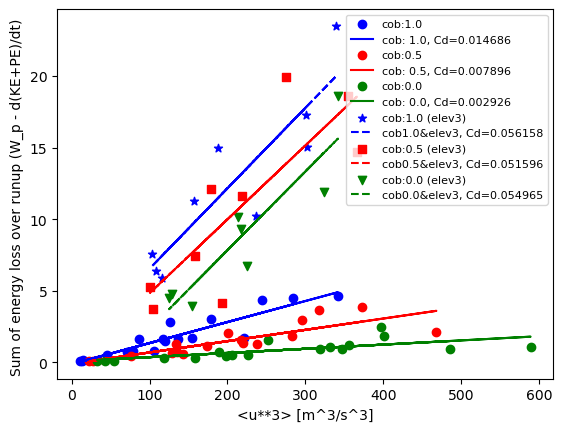

In [46]:


plt.scatter(u3_sum_cob10, eps1_sum_cob10, c='blue', marker='o', label='cob:1.0')
plt.plot(u3_sum_cob10, slope10 * u3_sum_cob10 + intercept10,  color='blue', label=f'cob: 1.0, Cd={slope10:.6f}')
# plt.scatter(u3_sum_cob10_slope1, eps1_sum_cob10_slope1, c='c', marker='s', label='cob:1.0 (slope1)')
# plt.scatter(u3_sum_cob10_slope2, eps1_sum_cob10_slope2, c='m', marker='s', label='cob:1.0 (slope2)')
plt.scatter(u3_sum_cob05, eps1_sum_cob05, c='red', marker='o', label='cob:0.5')
plt.plot(u3_sum_cob05, slope05 * u3_sum_cob05 + intercept05,  color='red', label=f'cob: 0.5, Cd={slope05:.6f}')
# plt.scatter(u3_sum_cob05_slope1, eps1_sum_cob05_slope1, c='c', marker='s', label='cob:0.5 (slope1)')
# plt.scatter(u3_sum_cob05_slope2, eps1_sum_cob05_slope2, c='m', marker='s', label='cob:0.5 (slope2)')
plt.scatter(u3_sum_cob00, eps1_sum_cob00, c='green', marker='o', label='cob:0.0')
plt.plot(u3_sum_cob00, slope00 * u3_sum_cob00 + intercept00,  color='green', label=f'cob: 0.0, Cd={slope00:.6f}')
# plt.scatter(u3_sum[6:-1:9], eps1_sum[6:-1:9], c='blue', marker='*', label='ele:1.5 & cob:1.0')
# plt.scatter(u3_sum[7:-1:9], eps1_sum[7:-1:9], c='red', marker='*', label='ele:0.5 & cob:0.5')
# plt.scatter(u3_sum[8:-1:9], eps1_sum[8:-1:9], c='green', marker='*', label='ele:0.0 & cob:0.0')
plt.scatter(u3_sum_cob10_elev3, eps1_sum_subtract_turb_cob10_elev3, c='blue', marker='*', label='cob:1.0 (elev3)')
plt.plot(u3_sum_cob10_elev3, slope10_subtract_turb * u3_sum_cob10_elev3 + intercept10_subtract_turb,  '--',color='blue', label=f'cob1.0&elev3, Cd={slope10_subtract_turb:.6f}')
plt.scatter(u3_sum_cob05_elev3, eps1_sum_subtract_turb_cob05_elev3, c='red', marker='s', label='cob:0.5 (elev3)')
plt.plot(u3_sum_cob05_elev3, slope05_subtract_turb * u3_sum_cob05_elev3 + intercept05_subtract_turb,  '--',color='red', label=f'cob0.5&elev3, Cd={slope05_subtract_turb:.6f}')
plt.scatter(u3_sum_cob00_elev3, eps1_sum_subtract_turb_cob00_elev3, c='green', marker='v', label='cob:0.0 (elev3)')
plt.plot(u3_sum_cob00_elev3, slope00_subtract_turb * u3_sum_cob00_elev3 + intercept00_subtract_turb,  '--',color='green', label=f'cob0.0&elev3, Cd={slope00_subtract_turb:.6f}')
plt.legend(loc='upper right', fontsize=8)
plt.ylabel("Sum of energy loss over runup (W_p - d(KE+PE)/dt) ")
plt.xlabel("<u**3> [m^3/s^3]")

# plt.plot(eps1_sum, umean_sum, 'o-')

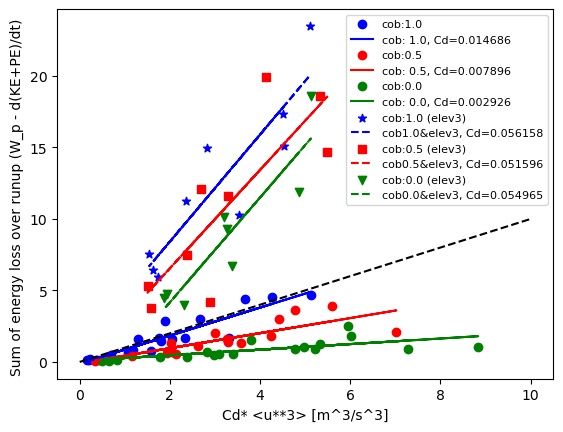

In [280]:
Cd = 0.015

plt.scatter(u3_sum_cob10*Cd, eps1_sum_cob10, c='blue', marker='o', label='cob:1.0')
plt.plot(u3_sum_cob10*Cd, slope10 * u3_sum_cob10 + intercept10,  color='blue', label=f'cob: 1.0, Cd={slope10:.6f}')
# plt.scatter(u3_sum_cob10_slope1, eps1_sum_cob10_slope1, c='c', marker='s', label='cob:1.0 (slope1)')
# plt.scatter(u3_sum_cob10_slope2, eps1_sum_cob10_slope2, c='m', marker='s', label='cob:1.0 (slope2)')
plt.scatter(u3_sum_cob05*Cd, eps1_sum_cob05, c='red', marker='o', label='cob:0.5')
plt.plot(u3_sum_cob05*Cd, slope05 * u3_sum_cob05 + intercept05,  color='red', label=f'cob: 0.5, Cd={slope05:.6f}')
# plt.scatter(u3_sum_cob05_slope1, eps1_sum_cob05_slope1, c='c', marker='s', label='cob:0.5 (slope1)')
# plt.scatter(u3_sum_cob05_slope2, eps1_sum_cob05_slope2, c='m', marker='s', label='cob:0.5 (slope2)')
plt.scatter(u3_sum_cob00*Cd, eps1_sum_cob00, c='green', marker='o', label='cob:0.0')
plt.plot(u3_sum_cob00*Cd, slope00 * u3_sum_cob00 + intercept00,  color='green', label=f'cob: 0.0, Cd={slope00:.6f}')
# plt.scatter(u3_sum[6:-1:9], eps1_sum[6:-1:9], c='blue', marker='*', label='ele:1.5 & cob:1.0')
# plt.scatter(u3_sum[7:-1:9], eps1_sum[7:-1:9], c='red', marker='*', label='ele:0.5 & cob:0.5')
# plt.scatter(u3_sum[8:-1:9], eps1_sum[8:-1:9], c='green', marker='*', label='ele:0.0 & cob:0.0')
plt.scatter(u3_sum_cob10_elev3*Cd, eps1_sum_subtract_turb_cob10_elev3, c='blue', marker='*', label='cob:1.0 (elev3)')
plt.plot(u3_sum_cob10_elev3*Cd, slope10_subtract_turb * u3_sum_cob10_elev3 + intercept10_subtract_turb,  '--',color='blue', label=f'cob1.0&elev3, Cd={slope10_subtract_turb:.6f}')
plt.scatter(u3_sum_cob05_elev3*Cd, eps1_sum_subtract_turb_cob05_elev3, c='red', marker='s', label='cob:0.5 (elev3)')
plt.plot(u3_sum_cob05_elev3*Cd, slope05_subtract_turb * u3_sum_cob05_elev3 + intercept05_subtract_turb,  '--',color='red', label=f'cob0.5&elev3, Cd={slope05_subtract_turb:.6f}')
plt.scatter(u3_sum_cob00_elev3*Cd, eps1_sum_subtract_turb_cob00_elev3, c='green', marker='v', label='cob:0.0 (elev3)')
plt.plot(u3_sum_cob00_elev3*Cd, slope00_subtract_turb * u3_sum_cob00_elev3 + intercept00_subtract_turb,  '--',color='green', label=f'cob0.0&elev3, Cd={slope00_subtract_turb:.6f}')
plt.legend(loc='upper right', fontsize=8)
plt.ylabel("Sum of energy loss over runup (W_p - d(KE+PE)/dt) ")
plt.xlabel("Cd* <u**3> [m^3/s^3]")

plt.plot([0,10], [0, 10], 'k--')


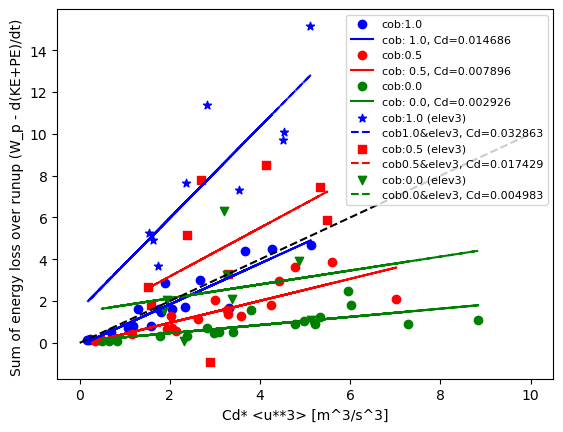

In [ ]:
Cd = 0.015



plt.scatter(u3_sum_cob10*Cd, eps1_sum_cob10, c='blue', marker='o', label='cob:1.0')
plt.plot(u3_sum_cob10*Cd, slope10 * u3_sum_cob10 + intercept10,  color='blue', label=f'cob: 1.0, Cd={slope10:.6f}')
# plt.scatter(u3_sum_cob10_slope1, eps1_sum_cob10_slope1, c='c', marker='s', label='cob:1.0 (slope1)')
# plt.scatter(u3_sum_cob10_slope2, eps1_sum_cob10_slope2, c='m', marker='s', label='cob:1.0 (slope2)')
plt.scatter(u3_sum_cob05*Cd, eps1_sum_cob05, c='red', marker='o', label='cob:0.5')
plt.plot(u3_sum_cob05*Cd, slope05 * u3_sum_cob05 + intercept05,  color='red', label=f'cob: 0.5, Cd={slope05:.6f}')
# plt.scatter(u3_sum_cob05_slope1, eps1_sum_cob05_slope1, c='c', marker='s', label='cob:0.5 (slope1)')
# plt.scatter(u3_sum_cob05_slope2, eps1_sum_cob05_slope2, c='m', marker='s', label='cob:0.5 (slope2)')
plt.scatter(u3_sum_cob00*Cd, eps1_sum_cob00, c='green', marker='o', label='cob:0.0')
plt.plot(u3_sum_cob00*Cd, slope00 * u3_sum_cob00 + intercept00,  color='green', label=f'cob: 0.0, Cd={slope00:.6f}')
# plt.scatter(u3_sum[6:-1:9], eps1_sum[6:-1:9], c='blue', marker='*', label='ele:1.5 & cob:1.0')
# plt.scatter(u3_sum[7:-1:9], eps1_sum[7:-1:9], c='red', marker='*', label='ele:0.5 & cob:0.5')
# plt.scatter(u3_sum[8:-1:9], eps1_sum[8:-1:9], c='green', marker='*', label='ele:0.0 & cob:0.0')
plt.scatter(u3_sum_cob10_elev3*Cd, eps1_sum_subtract_turb2_cob10_elev3, c='blue', marker='*', label='cob:1.0 (elev3)')
plt.plot(u3_sum_cob10*Cd, slope10_subtract_turb2 * u3_sum_cob10 + intercept10_subtract_turb2,  '--',color='blue', label=f'cob1.0&elev3, Cd={slope10_subtract_turb2:.6f}')
plt.scatter(u3_sum_cob05_elev3*Cd, eps1_sum_subtract_turb2_cob05_elev3, c='red', marker='s', label='cob:0.5 (elev3)')
plt.plot(u3_sum_cob05_elev3*Cd, slope05_subtract_turb2 * u3_sum_cob05_elev3 + intercept05_subtract_turb2,  '--',color='red', label=f'cob0.5&elev3, Cd={slope05_subtract_turb2:.6f}')
plt.scatter(u3_sum_cob00_elev3*Cd, eps1_sum_subtract_turb2_cob00_elev3, c='green', marker='v', label='cob:0.0 (elev3)')
plt.plot(u3_sum_cob00*Cd, slope00_subtract_turb2 * u3_sum_cob00 + intercept00_subtract_turb2,  '--',color='green', label=f'cob0.0&elev3, Cd={slope00_subtract_turb2:.6f}')
plt.legend(loc='upper right', fontsize=8)
plt.ylabel("Sum of energy loss over runup (W_p - d(KE+PE)/dt) ")
plt.xlabel("Cd* <u**3> [m^3/s^3]")

plt.plot([0,10], [0, 10], 'k--')

# plt.plot(eps1_sum, umean_sum, 'o-')

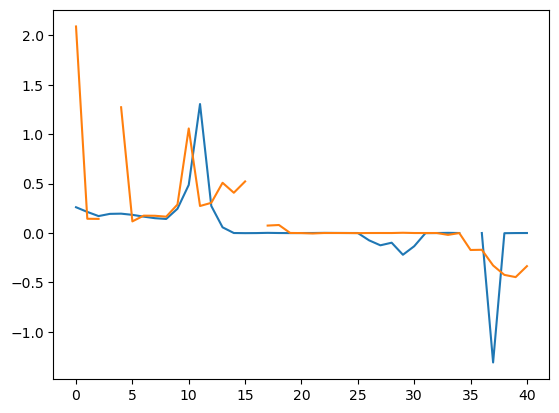

In [48]:
plt.plot(E_turb[6].T)
plt.plot(E_turb[0].T)
# plt.plot(E_turb[8].T)
# plt.colorbar()

In [172]:
ds_eta0.elevation.isel(t=16, y=10).values[635]

1.9357479009777308

In [149]:
loc_front[0,10]

699.0

(600.0, 900.0)

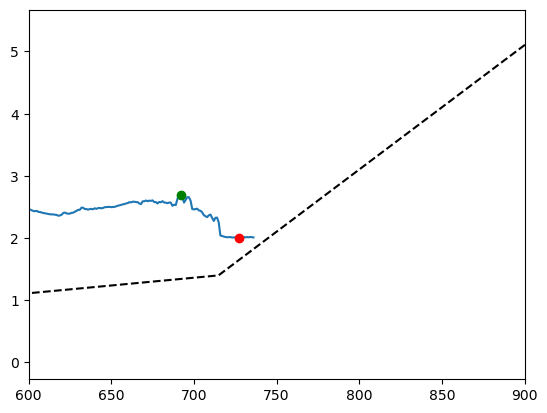

In [157]:
icase=6
ds_eta0 = xr.open_dataset(f'{fig_folder_a[icase]}/elev_Euler_all_output_v3.nc')
plt.plot(ds_eta0.elevation.isel(y=10).values[10])
plt.plot(loc_front[icase,10], ds_eta0.elevation.isel(y=10).values[10, int(loc_front[icase,10])], 'ro')
plt.plot(loc_front2[icase,10], ds_eta0.elevation.isel(y=10).values[10, int(loc_front2[icase,10])], 'go')
plt.plot(h_bot1, 'k--')
plt.xlim(600, 900)

In [33]:
# get froude number
fr_0 = ds_umean0.velocity.isel(t=t, y=10).values / np.sqrt(9.81 * (ds_eta0.elevation.isel(t=t, y=10).values - h_bot))
fr_6 = ds_umean6.velocity.isel(t=t, y=10).values / np.sqrt(9.81 * (ds_eta6.elevation.isel(t=t, y=10).values - h_bot))

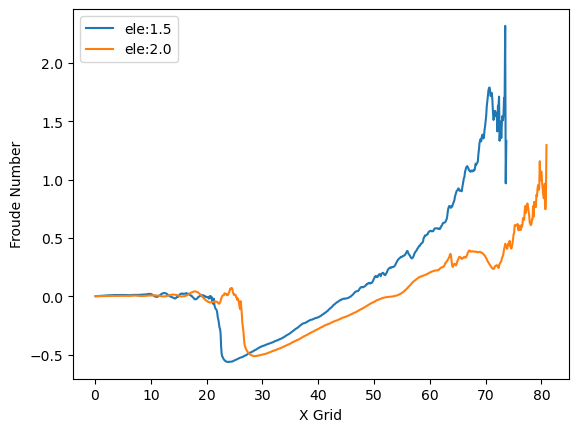

In [137]:
plt.plot(ds_umean0.x_grid, fr_0, label='ele:1.5')
plt.plot(ds_umean6.x_grid, fr_6, label='ele:2.0')
plt.xlabel('X Grid')
plt.ylabel('Froude Number')
plt.legend()


In [165]:
## get period, wave length and wave speed, 

icase = 6
ds_eta0 = xr.open_dataset(f"{fig_folder_a[icase]}/elev_Euler_all_output_v3.nc")
ds_eta00 = xr.open_dataset(f"{fig_folder_a[icase]}/elev_Euler_all_output_v3_0_50.nc")
elev_t = xr.concat([ds_eta00, ds_eta0], dim="t").elevation.isel(y=10).values

In [166]:
# k_max_eta = np.nanargmax(elev_t[:,200:], axis=1)+200
k_max_eta = np.nanargmax(elev_t[:,:], axis=1)
k_min_eta = np.nanargmin(elev_t[:,:], axis=1)
elev_peak = np.zeros((91))
x_peak = np.zeros((91))
x_trough = np.zeros((91))
for i in range(91):
    elev_peak[i] = elev_t[i, k_max_eta[i]]
    x_peak[i] = ds_eta0.x_grid.values[k_max_eta[i]]
    x_trough[i] = ds_eta0.x_grid.values[k_min_eta[i]]


L = x_peak - x_trough

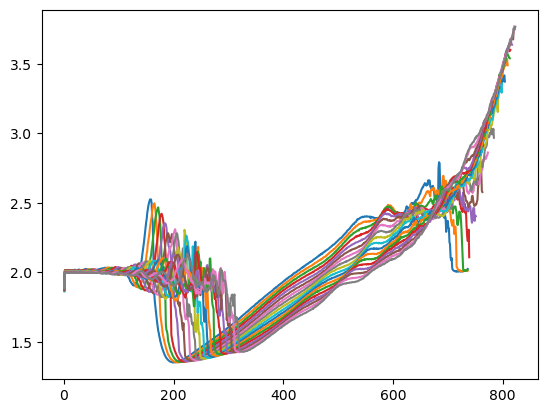

In [169]:
plt.plot(elev_t[59:77,:].T)
# for i in range(91):
#     plt.plot(k_max_eta[i], elev_t[i, k_max_eta[i]], 'ro')
# plt.plot(k_max_eta, elev_t[:, k_max_eta[50]+200], 'ro')
# plt.plot(elev_t[40,:])
# plt.plot(elev_t[60,:])

In [192]:
period_all = np.zeros((81))
c_wave_all = np.zeros((81,41))
c_wave_mean_all = np.zeros((81))
for icase in tqdm(range(81)):

    ds_eta0 = xr.open_dataset(f"{fig_folder_a[icase]}/elev_Euler_all_output_v3.nc")
    ds_eta00 = xr.open_dataset(f"{fig_folder_a[icase]}/elev_Euler_all_output_v3_0_50.nc")
    elev_t = xr.concat([ds_eta00, ds_eta0], dim="t").elevation.isel(y=10).values

    k_max_eta = np.nanargmax(elev_t[:,:], axis=1)
    k_min_eta = np.nanargmin(elev_t[:,:], axis=1)
    elev_peak = np.zeros((91))
    x_peak = np.zeros((91))
    x_trough = np.zeros((91))
    for i in range(91):
        elev_peak[i] = elev_t[i, k_max_eta[i]]
        x_peak[i] = ds_eta0.x_grid.values[k_max_eta[i]]
        x_trough[i] = ds_eta0.x_grid.values[k_min_eta[i]]


    L = 2*(x_peak - x_trough)
    c_wave = np.diff(x_peak)/0.25

    L_mean = np.nanmean(L[time_toe_all[icase]:troughs_in_original_all[icase][0]+50])
    c_wave_mean = np.nanmean(c_wave[time_toe_all[icase]:troughs_in_original_all[icase][0]+50-1])

    period_all[icase] = L_mean / c_wave_mean
    c_wave_all[icase, :] = c_wave[49:90]
    c_wave_mean_all[icase] = c_wave_mean


100%|██████████| 81/81 [00:10<00:00,  7.83it/s]


In [121]:
c_wave = np.diff(x_peak)/0.25

(3.066666666666666, 51.22222222222223)

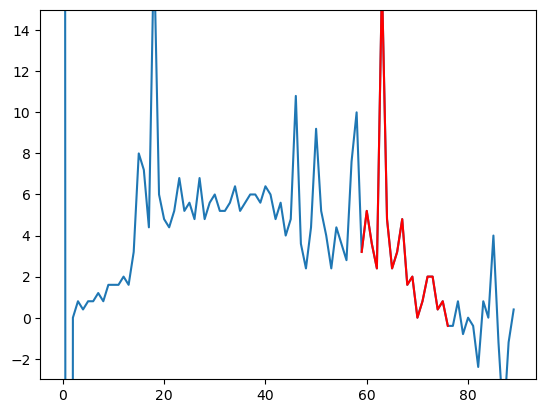

In [144]:
plt.plot(c_wave[:])
plt.plot(range(59,77), c_wave[59:77], 'r')
plt.ylim(-3, 15)

np.mean(c_wave[59:77]), np.mean(L[59:77])

In [128]:
time_toe_all[6], troughs_in_original_all[6][0]+50

(59, 77)

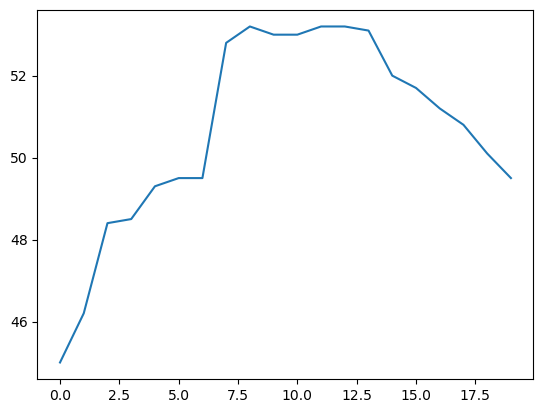

In [140]:
plt.plot(L[57:77])

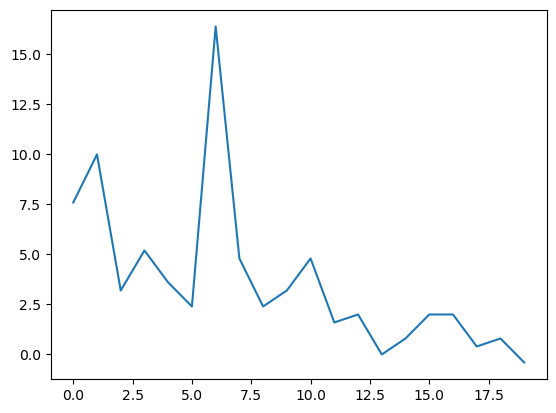

In [141]:
plt.plot(c_wave[57:77])

/tmp/ipykernel_863323/907627512.py:1: RuntimeWarning: divide by zero encountered in divide
  plt.plot(L[57:77]/c_wave[57:77])


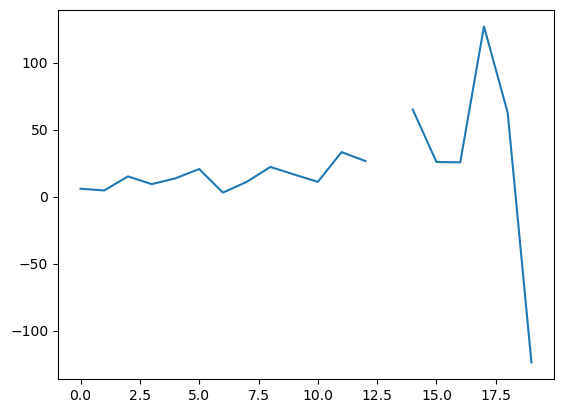

In [142]:
plt.plot(L[57:77]/c_wave[57:77])

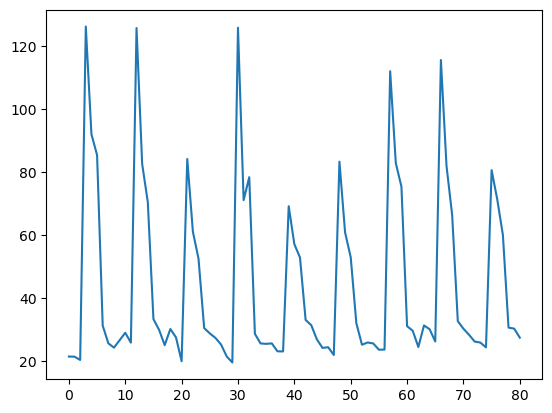

In [172]:
plt.plot(period_all[0:])

In [149]:
L_mean

nan